In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
mainfolder = '/content/drive/MyDrive/Trabajos/diHiggs/with_scalars/pythons/'

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import itertools

from scipy.optimize import fsolve, minimize

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

## DATA

### Background

In [4]:
CHs_selected = ["bbaa", "tth", "zh"]


df_B_all = {}
X_B_all = {}

N_B_all = {}


output_folder = mainfolder + "../DATA/backgrounds/data_df/"

for CH_sel in CHs_selected:
    # Read the file
    file_path = output_folder + "df_" + CH_sel + ".csv"

    df_temp = pd.read_csv(file_path)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_B_all[CH_sel] = df_temp
    X_B_all[CH_sel] = df_temp[feats_label].values
    # X_B_all[CH_sel] = df_temp['m_phopho'].values[:, None]
    N_B_all[CH_sel] = len(df_temp)

    # Print
    print(f"X_{CH_sel}.shape: {X_B_all[CH_sel].shape}")

X_bbaa.shape: (129262, 26)
X_tth.shape: (154321, 26)
X_zh.shape: (57657, 26)


In [5]:
X_B_all["zh"].shape

(57657, 26)

### Signal

In [6]:
BPs_selected = ["BP1", "BP28", "BP62", "BP63", "BP219",
                "BP220", "BP586", "BP635", "BP658", "BP673",
                "BP678", "BP684", "BP685", "BP728", "BP732",
                "BP752", "BP754", "BP758", "BP763", "BP765",
                "BP787", "BP791", "BP826", "BP841", "BP850",
                "BP855","BP872", "BP875", "BP881", "BP1017",
                "BP1035", "BP1036", "BP1087", "BP1103", "BP1104"]


df_S_all = {}
X_S_all = {}

N_S_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for BP_sel in BPs_selected:
    # Read the file
    file_path = output_folder + "df_" + BP_sel + ".csv"

    df_temp = pd.read_csv(file_path)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_S_all[BP_sel] = df_temp
    X_S_all[BP_sel] = df_temp[feats_label].values
    # X_S_all[BP_sel] = df_temp['m_phopho'].values[:, None]
    N_S_all[BP_sel] = len(df_temp)

    # Print
    print(f"X_{BP_sel}.shape: {X_S_all[BP_sel].shape}")

X_BP1.shape: (153551, 26)
X_BP28.shape: (7300, 26)
X_BP62.shape: (7736, 26)
X_BP63.shape: (8062, 26)
X_BP219.shape: (7590, 26)
X_BP220.shape: (11096, 26)
X_BP586.shape: (11057, 26)
X_BP635.shape: (7258, 26)
X_BP658.shape: (6823, 26)
X_BP673.shape: (3708, 26)
X_BP678.shape: (6903, 26)
X_BP684.shape: (11225, 26)
X_BP685.shape: (10343, 26)
X_BP728.shape: (10263, 26)
X_BP732.shape: (6848, 26)
X_BP752.shape: (6785, 26)
X_BP754.shape: (7377, 26)
X_BP758.shape: (7423, 26)
X_BP763.shape: (6727, 26)
X_BP765.shape: (7005, 26)
X_BP787.shape: (7734, 26)
X_BP791.shape: (6704, 26)
X_BP826.shape: (7178, 26)
X_BP841.shape: (6941, 26)
X_BP850.shape: (7324, 26)
X_BP855.shape: (7321, 26)
X_BP872.shape: (7114, 26)
X_BP875.shape: (7201, 26)
X_BP881.shape: (7209, 26)
X_BP1017.shape: (7060, 26)
X_BP1035.shape: (7039, 26)
X_BP1036.shape: (7165, 26)
X_BP1087.shape: (7171, 26)
X_BP1103.shape: (7260, 26)
X_BP1104.shape: (7063, 26)


In [7]:
X_S_all["BP28"].shape

(7300, 26)

In [8]:
BPs_selected = ["BP0"]


df_S0_all = {}
X_S0_all = {}

N_S0_all = {}


output_folder = mainfolder + "../DATA/SMhiggs-v2/data_df/"

for BP_sel in BPs_selected:
    # Read the file
    file_path = output_folder + "df_" + BP_sel + ".csv"

    df_temp = pd.read_csv(file_path)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_S0_all[BP_sel] = df_temp
    X_S0_all[BP_sel] = df_temp[feats_label].values
    N_S0_all[BP_sel] = len(df_temp)

    # Print
    print(f"X_{BP_sel}.shape: {X_S0_all[BP_sel].shape}")

X_BP0.shape: (35675, 26)


#### Name of the features

In [9]:
feats_label

['num_photons',
 'num_jets',
 'num_btag',
 'MET_pT',
 'MET_phi',
 'photon1_pT',
 'photon1_eta',
 'photon1_phi',
 'photon2_pT',
 'photon2_eta',
 'photon2_phi',
 'btag1_pt',
 'btag1_eta',
 'btag1_phi',
 'btag2_pt',
 'btag2_eta',
 'btag2_phi',
 'm_hh',
 'm_phopho',
 'm_bb',
 'pT_hh',
 'pT_phopho',
 'pT_bb',
 'dR_hh',
 'dR_phopho',
 'dR_bb']

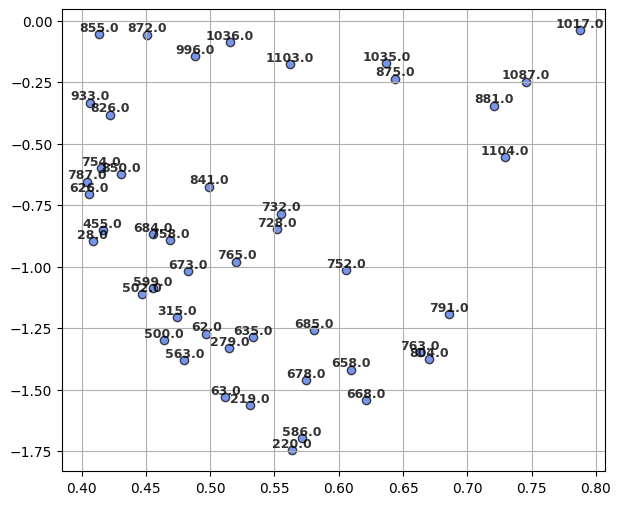

Number of the selected BPs:


array([ 502.,  315.,  455.,  586.,   62.,  219.,  279.,  599.,   28.,
        500.,   63.,  563.,  220.,  684.,  658.,  635.,  626.,  673.,
        678.,  668.,  685.,  787.,  841.,  850.,  763.,  728.,  765.,
        826.,  732.,  804.,  758.,  752.,  754.,  791., 1017.,  855.,
       1103.,  881., 1036.,  872.,  875.,  996., 1035., 1087.,  933.,
       1104.])

In [10]:
# LOAD THE BP VARIABLES

BP_dat, mu1, mu2, lam3, senthetaU, C22, Q22, ratioxsec, xsecTH, xsecMG = np.loadtxt(mainfolder + '../DATA/signal/BPdata.txt', unpack=True, comments='#')

# Plot
var_x = mu2
var_y = C22

plt.figure(figsize=(7, 6))
plt.scatter(var_x, var_y, color='royalblue', alpha=0.7, edgecolors='k')

for i_bp in range(len(BP_dat)):
    plt.text(var_x[i_bp], var_y[i_bp], str(BP_dat[i_bp]),
            color='black',
            fontsize=9,
            ha='center',      # Alineación horizontal al centro
            va='bottom',      # Alineación vertical al centro
            alpha=0.8,
            fontweight='bold')

# plt.xlabel(r'$m_{U2}$ [TeV]', fontsize=13)
# plt.ylabel(r'$\lambda_3$', fontsize=13)
plt.grid(True)
plt.show()



# to dictionaries
mu1_dic = {}
mu2_dic = {}
lam3_dic = {}
senthetaU_dic = {}
C22_dic = {}
Q22_dic = {}
ratioxsec_dic = {}
xsecTH_dic = {}
xsecMG_dic = {}


for i_bp in range(len(BP_dat)):
    mu1_dic["BP"+str(int(BP_dat[i_bp]))] = mu1[i_bp]
    mu2_dic["BP"+str(int(BP_dat[i_bp]))] = mu2[i_bp]
    lam3_dic["BP"+str(int(BP_dat[i_bp]))] = lam3[i_bp]
    senthetaU_dic["BP"+str(int(BP_dat[i_bp]))] = senthetaU[i_bp]
    C22_dic["BP"+str(int(BP_dat[i_bp]))] = C22[i_bp]
    Q22_dic["BP"+str(int(BP_dat[i_bp]))] = Q22[i_bp]
    ratioxsec_dic["BP"+str(int(BP_dat[i_bp]))] = ratioxsec[i_bp]
    xsecTH_dic["BP"+str(int(BP_dat[i_bp]))] = xsecTH[i_bp]
    xsecMG_dic["BP"+str(int(BP_dat[i_bp]))] = xsecMG[i_bp]



print('Number of the selected BPs:')
BP_dat

In [11]:
# LOAD THE BP VARIABLES

BP_datLET, xsecLET = np.loadtxt(mainfolder + '../DATA/signal/BPdataLET.txt', unpack=True, comments='#')


# to dictionaries
xsecLET_dic = {}


for i_bp in range(len(BP_datLET)):
    xsecLET_dic["BP"+str(int(BP_datLET[i_bp]))] = xsecLET[i_bp]



print(xsecTH_dic['BP63'])
print(xsecMG_dic['BP63'])
print(xsecLET_dic['BP63'])

33.6409
0.030111
34.52567925584715


<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4139/2378890448.py:18: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Limits due to $\delta \kappa_g$ and $\delta \kappa_{\gamma}$')


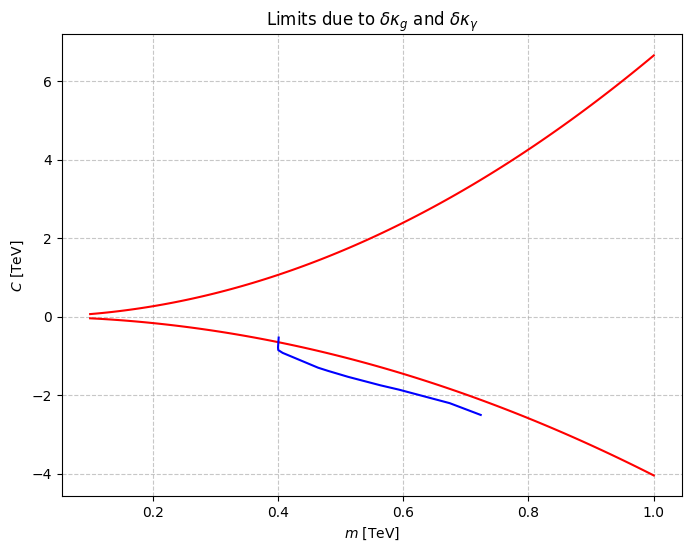

In [12]:
# LOAD CONSTRAINTS
# unpack=True to asign a variable to each column
mC1, mu_lowC1, mu_highC1 = np.loadtxt(mainfolder + '../DATA/signal/limits_mu_m.txt', unpack=True)
mC2, mu_lowC2 = np.loadtxt(mainfolder + '../DATA/signal/frontera_elipse_m_mu.txt', unpack=True)

# Plot
plt.figure(figsize=(8, 6))

# plt.fill_between(mC1, mu_lowC, mu_highC1, color='orange', alpha=0.3, label='Allowed')

plt.plot(mC1, mu_lowC1, color='red', lw=1.5)
plt.plot(mC1, mu_highC1, color='red', lw=1.5)

plt.plot(mC2, mu_lowC2, color='blue', lw=1.5)

plt.xlabel(r'$m$ [TeV]')
plt.ylabel(r'$C$ [TeV]')
plt.title('Limits due to $\delta \kappa_g$ and $\delta \kappa_{\gamma}$')
plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend()

plt.show()


### LOAD THE FIDUCIAL CROSS SECTIONS

In [13]:
# CROSS-SECTION

luminosity = 3000 # fb**-1


# BACKGROUND
df = pd.read_csv(mainfolder + '../DATA/backgrounds/fidxsec_B.txt',
                 sep='\s+',
                 comment='#',
                 names=['channel', 'fidxsec'])

B_expected_all = {}

for it in range(len(df)):
    B_expected_all[df['channel'][it]] = df['fidxsec'].values[it] * luminosity



# SIGNAL
df = pd.read_csv(mainfolder + '../DATA/signal/fidxsec_S.txt',
                 sep='\s+',
                 comment='#',
                 names=['BP', 'fidxsec'])

S_expected_all = {}

for it in range(len(df)):
    S_expected_all[df['BP'][it]] = df['fidxsec'].values[it] * luminosity




print("For L=", luminosity, " [fb-1]")


print('\nBACKGROUND:\n')
print(f"{'Process':<15} | {'# events expected':>12}")
print("-" * 35)

for channel, fid_xsec in B_expected_all.items():
    # :<15 alinea a la izquierda con 15 espacios
    # :>12.4f alinea a la derecha, 12 espacios y 4 decimales
    print(f"{channel:<15} | {fid_xsec:>15.4f}")


print('\n SIGNAL:\n')
print(f"{'BP':<15} | {'# events expected':>12}")
print("-" * 35)

for BP, fid_xsec in S_expected_all.items():
    print(f"{BP:<15} | {fid_xsec:>15.4f}")

print('\n')

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4139/656833712.py:8: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_4139/656833712.py:21: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


For L= 3000  [fb-1]

BACKGROUND:

Process         | # events expected
-----------------------------------
bbaa            |       1146.6587
bbaj_NOFAKES    |       7344.0146
bbaj            |       8572.2164
tth             |         25.7944
zh              |         13.5837

 SIGNAL:

BP              | # events expected
-----------------------------------
BP1             |         63.9083
BP28            |         60.5850
BP62            |         45.6197
BP63            |         55.1528
BP219           |         49.7810
BP220           |         44.7572
BP586           |         43.3166
BP635           |         38.3463
BP658           |         31.6976
BP673           |         39.1702
BP678           |         36.2341
BP684           |         39.5540
BP685           |         32.0820
BP728           |         27.5732
BP732           |         27.6409
BP752           |         27.2018
BP754           |         34.2380
BP758           |         34.9220
BP763           |         35.

In [14]:
S_expected_BP0 = 0.008153245887045598 * luminosity

print('S_expected_BP0: ', S_expected_BP0)

S_expected_BP0:  24.459737661136796


In [15]:

# SIGNAL
df = pd.read_csv(mainfolder + '../DATA/signal/xsec_S.txt',
                 sep='\s+',
                 comment='#',
                 names=['BP', 'fidxsec', 'MG_xsec', 'Cut1_xsec'])

xsec_all = {}

for it in range(len(df)):
    xsec_all[df['BP'][it]] = df[['MG_xsec', 'Cut1_xsec','fidxsec']].values[it]




print("For 14 TeV")





print('\n SIGNAL:\n')
print(f"{'BP':<15} | {'MG xsec   basic cuts xsec   fid xsec  [fb]':>25}")
print("-" * 35)

for BP, xsec in xsec_all.items():
    print(f"{BP:<15} | {xsec} ")

print('\n')

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4139/3044148671.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


For 14 TeV

 SIGNAL:

BP              | MG xsec   basic cuts xsec   fid xsec  [fb]
-----------------------------------
BP1             | [0.32539385 0.02632127 0.02130278] 
BP28            | [0.31160615 0.02498924 0.020195  ] 
BP62            | [0.25658144 0.01949767 0.01520657] 
BP63            | [0.29856774 0.02347632 0.01838428] 
BP219           | [0.28618307 0.0213313  0.01659368] 
BP220           | [0.26368126 0.01944211 0.01491906] 
BP586           | [0.25761769 0.01899502 0.01443888] 
BP635           | [0.23004622 0.01690133 0.01278211] 
BP658           | [0.20199047 0.01398356 0.01056587] 
BP673           | [0.22914397 0.01693359 0.01305672] 
BP678           | [0.22835564 0.01603229 0.01207802] 
BP684           | [0.23024137 0.01697035 0.01318467] 
BP685           | [0.20209956 0.0140998  0.01069401] 
BP728           | [0.17491665 0.01204966 0.00919106] 
BP732           | [0.17536721 0.01214537 0.00921364] 
BP752           | [0.17419063 0.01197121 0.00906728] 
BP754           |

# AUX functions

In [16]:
def generate_pseudo_1output_dis(scores_B, scores_S, N_B, N_S):

    sB = np.random.choice(scores_B, N_B, replace=True)
    sS = np.random.choice(scores_S, N_S, replace=True)

    scores = np.concatenate([sB, sS])

    return scores


def generate_pseudo_1output_exc(scores_B, N_B):

    sB = np.random.choice(scores_B, N_B, replace=True)

    return sB


In [17]:
def Z_asimov_dis(S, B):
    return np.sqrt( 2 * np.sum( (S+B) * np.log(1 + S/B) - S ) )


def Z_asimov_exc(S, B):
    return np.sqrt( 2 * np.sum( S - B * np.log(1 + S/B) ) )




def Z_simple_nan(S, B):
    return np.sum( np.nan_to_num( S / np.sqrt(B), copy=False, nan=0.0) )


def Z_asimov_dis_nan(S, B):
    return np.sqrt( 2 * np.sum( np.nan_to_num((S+B) * np.log(1 + S/B) - S, copy=False, nan=0.0) ) )


def Z_asimov_exc_nan(S, B):
    return np.sqrt( 2 * np.sum( np.nan_to_num(S - B * np.log(1 + S/B), copy=False, nan=0.0) ) )



In [18]:

def f_mu_hat(mu, N, S, B):

    return sum((ni*si)/(mu*si+bi) - si for ni,si,bi in zip(N,S,B))


def q0(N,S,B,mu_hat):
    """
    this is for discovery
    q0 = −2 log( L(0)/L(μ^) )
    """
    if mu_hat <= 0:
        return 0

    return -2 * sum( ni*np.log((bi)/(mu_hat*si+bi)) - bi + (mu_hat*si+bi) for ni,si,bi in zip(N,S,B)  )


def q1(N,S,B,mu_hat):
    """
    this is for exclusion
    q1 = −2 log( L(1)/L(μ^) )
    """
    if mu_hat > 1:
        return 0
    elif mu_hat > 0:
        return -2 * sum( ni*np.log((si+bi)/(mu_hat*si+bi)) - (1-mu_hat)*si  for ni,si,bi in zip(N,S,B)  )
    else:
        return -2 * sum( ni*np.log((si+bi)/(0.*si+bi)) - (1-0.)*si  for ni,si,bi in zip(N,S,B)  )

# ALL BPs

In [19]:
BP_used = [1, 28, 62, 63, 219, 220, 586, 635, 658, 673, 678, 684, 685, 728, 732,
          752, 754, 758, 763, 765, 787, 791, 826, 841, 850, 855, 872, 875, 881,
          1017, 1035, 1036, 1087, 1103, 1104]

## Number of events per type (to get balanced dataset)

##### fakes bbaa

In [20]:
B_expected_bbaa_fakesonly = B_expected_all["bbaj"] - B_expected_all["bbaj_NOFAKES"]
print("B_expected_bbaj (FAKES ONLY): ", B_expected_bbaa_fakesonly)

B_expected_bbaj (FAKES ONLY):  1228.201796837765


In [21]:
# TOTAL BACKGROUND EXPECTED
B_expected = B_expected_all["bbaa"] + B_expected_all["tth"] + B_expected_all["zh"] + B_expected_bbaa_fakesonly
print("B_expected: ", B_expected)


# fraction of each channel
frac_B_all = {}
frac_B_all["bbaa"] = (B_expected_all["bbaa"] + B_expected_bbaa_fakesonly) / B_expected
frac_B_all["tth"] = B_expected_all["tth"] / B_expected
frac_B_all["zh"] = B_expected_all["zh"] / B_expected

print(" frac_bbaa:", frac_B_all["bbaa"])
print(" frac_tth:", frac_B_all["tth"])
print(" frac_zh:", frac_B_all["zh"], "\n")

B_expected:  2414.238598972644
 frac_bbaa: 0.983689220854325
 frac_tth: 0.010684267264551543
 frac_zh: 0.005626511881123403 



In [22]:
# 1. Calculamos el máximo Background total posible respetando las proporciones
# Evitamos división por cero si alguna fracción es 0
B_max_possible = min([N_B_all[k] / frac_B_all[k] for k in N_B_all if N_B_all[k] > 0])


# 1. Calculamos el máximo Signal total posible respetando las proporciones
# Evitamos división por cero si alguna fracción es 0
frac_signal=1.0/len(BP_used)

S_max_possible = min([N_S_all[k] / frac_signal for k in N_S_all if N_S_all[k] > 0])

# 2. Para un dataset balanceado S = B, el límite final lo pone la Señal vs B_max
total_per_class = min(S_max_possible, B_max_possible)

print(f"Total de eventos por clase (S y B): {int(total_per_class)}")

# 3. Calculamos cuántos eventos exactos sacar de cada componente

n_to_sample_S = int(total_per_class * frac_signal)

n_to_sample_B_all = {}
for k in frac_B_all:
    n_to_sample_B_all[k] = int(total_per_class * frac_B_all[k])

print('')
print(f"bbaa: {n_to_sample_B_all["bbaa"]}")
print(f"tth: {n_to_sample_B_all["tth"]}")
print(f"zh: {n_to_sample_B_all["zh"]}")


sumB = n_to_sample_B_all["bbaa"] + n_to_sample_B_all["tth"] + n_to_sample_B_all["zh"]
print('sum B: ', sumB)

sumS = n_to_sample_S * len(BP_used)
print('\n# BPs: ', len(BP_used))
print('events per BP: ', n_to_sample_S)
print('sum S: ', sumS)

Total de eventos por clase (S y B): 129780

bbaa: 127663
tth: 1386
zh: 730
sum B:  129779

# BPs:  35
events per BP:  3708
sum S:  129780


### Construct the dataset

In [23]:

labels_BP = np.concatenate( [[f'BP{bp_it}'] * n_to_sample_S for bp_it in BP_used] +
                            [["bbaa"]*n_to_sample_B_all["bbaa"]] +
                            [["tth"]*n_to_sample_B_all["tth"]] +
                            [["zh"]*n_to_sample_B_all["zh"]] )


X = np.vstack( [X_S_all[f'BP{bp_it}'][:n_to_sample_S] for bp_it in BP_used] +
               [X_B_all["bbaa"][:n_to_sample_B_all["bbaa"]]] +
               [X_B_all["tth"][:n_to_sample_B_all["tth"]]] +
               [X_B_all["zh"][:n_to_sample_B_all["zh"]]] )


y = np.concatenate([
    np.ones(n_to_sample_S*len(BP_used)),
    np.zeros(n_to_sample_B_all["bbaa"]),
    np.zeros(n_to_sample_B_all["tth"]),
    np.zeros(n_to_sample_B_all["zh"])
])




# NORMALIZATION

scaler = StandardScaler()
X = scaler.fit_transform(X)



X_trainval, X_test, y_trainval, y_test, BP_trainval, BP_test = train_test_split(
    X, y, labels_BP,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val, BP_train, BP_val = train_test_split(
    X_trainval, y_trainval, BP_trainval,
    test_size=0.25,  # 0.25 * 0.8 = 0.20 total
    stratify=y_trainval,
    random_state=42
)


print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (155735, 26)
Val: (51912, 26)
Test: (51912, 26)


In [24]:
X0 = X_S0_all["BP0"][:n_to_sample_S]

y0 = np.concatenate([
    np.ones(len(X0))
])

X0_scaled = scaler.transform(X0)

print(X0_scaled.shape)

print('S_expected_BP0: ', S_expected_BP0)

(3708, 26)
S_expected_BP0:  24.459737661136796


ROC AUC (SM vs LQ): 0.9841


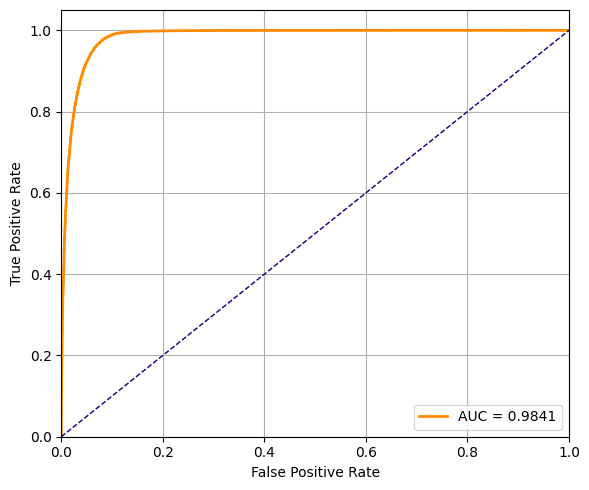

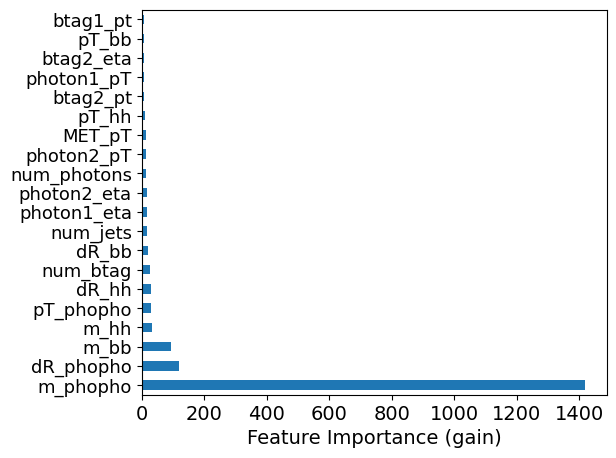

In [25]:
# LOAD
classifier_hh = XGBClassifier()
classifier_hh.load_model(mainfolder + "saved-models/classifier_hh_BPs_Colab.json")


# ------------------------------------------
# PREDICTION
# ------------------------------------------
y_pred = classifier_hh.predict_proba(X_test)[:,1]


# Compute ROC curve and AUC
# roc_auc_score(y_test, y_pred, sample_weight=w_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc_hh = auc(fpr, tpr)

print(f"ROC AUC (SM vs LQ): {roc_auc_hh:.4f}")

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_hh:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('ROC Curve:')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(mainfolder + 'saved-figures/ROC_allBP.pdf', bbox_inches='tight')
plt.show()







feature_important = classifier_hh.get_booster().get_score(importance_type='gain')

# convertir f0, f1, f2... a índices
importance_dict = {}

for k, v in feature_important.items():
    idx = int(k[1:])  # quitar la 'f'
    importance_dict[feats_label[idx]] = v

data = (
    pd.DataFrame.from_dict(importance_dict, orient="index", columns=["score"])
    .sort_values(by="score", ascending=False)
)

data.nlargest(20, "score").plot(kind='barh', figsize=(6,5))
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
# plt.title("Feature importance", fontsize=14)
plt.savefig(mainfolder + 'saved-figures/feats_allBP.pdf', bbox_inches='tight')
plt.show()

### Significance

#### using a threshold

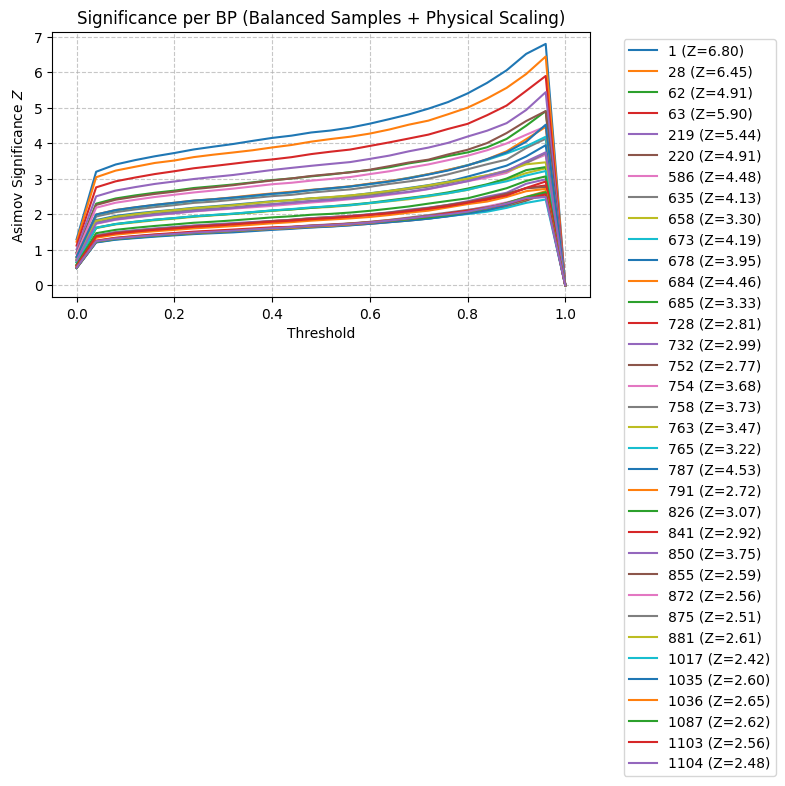

------------------------------
         1 | Zmax = 6.802 | at t = 0.960 |      S(o(x)>t) = 40.562
        28 | Zmax = 6.447 | at t = 0.960 |      S(o(x)>t) = 38.119
        62 | Zmax = 4.907 | at t = 0.960 |      S(o(x)>t) = 27.922
        63 | Zmax = 5.899 | at t = 0.960 |      S(o(x)>t) = 34.414
       219 | Zmax = 5.442 | at t = 0.960 |      S(o(x)>t) = 31.389
       220 | Zmax = 4.909 | at t = 0.960 |      S(o(x)>t) = 27.935
       586 | Zmax = 4.476 | at t = 0.960 |      S(o(x)>t) = 25.189
       635 | Zmax = 4.128 | at t = 0.960 |      S(o(x)>t) = 23.018
       658 | Zmax = 3.295 | at t = 0.960 |      S(o(x)>t) = 17.961
       673 | Zmax = 4.186 | at t = 0.960 |      S(o(x)>t) = 23.372
       678 | Zmax = 3.947 | at t = 0.960 |      S(o(x)>t) = 21.902
       684 | Zmax = 4.463 | at t = 0.960 |      S(o(x)>t) = 25.104
       685 | Zmax = 3.331 | at t = 0.960 |      S(o(x)>t) = 18.171
       728 | Zmax = 2.813 | at t = 0.960 |      S(o(x)>t) = 15.127
       732 | Zmax = 2.986 | at 

In [26]:
###################
#   for each BP   #
###################

thresholds = np.linspace(0, 1, 26)
results = {}

# Pre-calculamos la predicción del background para no repetir el filtro en cada loop
y_pred_B = y_pred[y_test == 0]
n_B_test = len(y_pred_B)


plt.figure(figsize=(8, 6))

for bp_it in BP_used:
    # Filtramos las predicciones solo de este BP
    y_pred_S_bp = y_pred[BP_test == f'BP{bp_it}']
    n_S_test_bp = len(y_pred_S_bp)

    # Obtenemos su S_expected
    S_bp = S_expected_all[f'BP{bp_it}']

    Z_values_bp = []

    for t in thresholds:
        # Eficiencias para este threshold
        eff_S = np.sum(y_pred_S_bp > t) / n_S_test_bp
        eff_B = np.sum(y_pred_B > t) / n_B_test

        # Escalado físico
        S = S_bp * eff_S
        B = B_expected * eff_B

        if B > 1e-6:
            Z = np.sqrt(2 * ((S + B) * np.log1p(S / B) - S))
        else:
            Z = 0
        Z_values_bp.append(Z)

    Z_values_bp = np.array(Z_values_bp)
    best_idx = np.argmax(Z_values_bp)

    eff_bp = np.mean(y_pred[BP_test == f'BP{bp_it}'] > thresholds[best_idx])
    yield_bp  = S_bp * eff_bp

    # Guardar resultados
    results[bp_it] = {
        "Zmax": Z_values_bp[best_idx],
        "threshold": thresholds[best_idx],
        "eff": eff_bp,
        "yield": yield_bp
    }

    # Plotear directamente en el mismo loop
    plt.plot(thresholds, Z_values_bp, label=f"{bp_it} (Z={Z_values_bp[best_idx]:.2f})")

# Finalizar el plot
plt.xlabel("Threshold")
plt.ylabel("Asimov Significance $Z$")
plt.title("Significance per BP (Balanced Samples + Physical Scaling)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Imprimir resumen
ZZ = []
print("-" * 30)
for bp_it, res in results.items():
    print(f"{bp_it:10} | Zmax = {res['Zmax']:.3f} | at t = {res['threshold']:.3f} |      S(o(x)>t) = {res['yield']:.3f}")
    ZZ.append(res['Zmax'])

#### Log-likelihood (25 bins)

In [27]:
n_pseudo = 1000

N_bins = 25

# SM PDF
hist_SM, edges = np.histogram(y_pred_B, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(y_pred_B) / B_expected)

In [28]:
# valor mínimo de eventos de fondo y su posición (índice del bin)
min_B_events = np.min(B_template)
min_B_idx = np.argmin(B_template)

# bordes del bin específico
bin_left_edge = edges[min_B_idx]
bin_right_edge = edges[min_B_idx + 1]

print(f"Número mínimo de eventos esperados en un bin: {min_B_events:.5f}")
print(f"Índice del bin con el mínimo: {min_B_idx} (de {N_bins} bins totales)")
print(f"Rango del bin: [{bin_left_edge:.3f}, {bin_right_edge:.3f}]")

# warning
if min_B_events < 5:
    print("\n THERE ARE NOT ENOUGH BACKGROUND EVENTS IN SOME BIN")

Número mínimo de eventos esperados en un bin: 7.99910
Índice del bin con el mínimo: 12 (de 25 bins totales)
Rango del bin: [0.480, 0.520]


<>:104: SyntaxWarning: invalid escape sequence '\h'
<>:104: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_4139/172130186.py:104: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$q(\hat{\mu})$",fontsize=16)


BP:  1
B_expected:  2414.238598972644
S_expected:  63.908347098737096

 Asimov datasets:
Z_asim_dis =  7.226397185787108
Z_asim_exc =  6.224803328849809



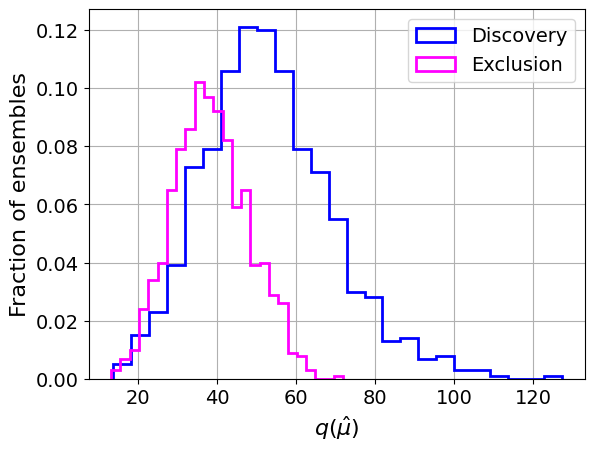


 Binned Likelihood:
Z_dis =  7.172874165264102  +-  1.1469742748431284
Z_exc =  6.157285829074557  +-  0.7767175388006615


------------------------------------------

BP:  28
B_expected:  2414.238598972644
S_expected:  60.585012455721

 Asimov datasets:
Z_asim_dis =  6.773831448175402
Z_asim_exc =  5.863037716919243



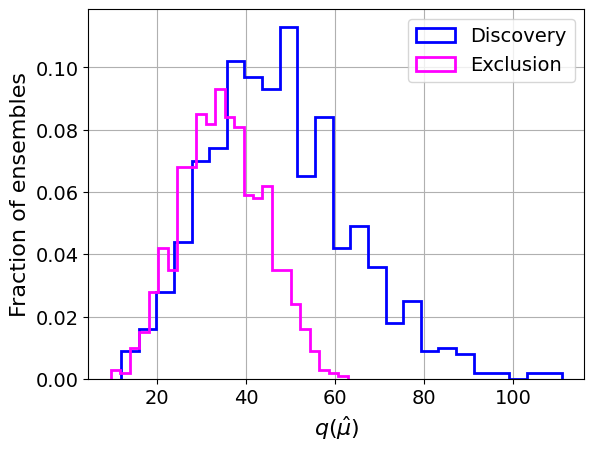


 Binned Likelihood:
Z_dis =  6.784626466274864  +-  1.1886023588309191
Z_exc =  5.866729020043191  +-  0.7900600398926145


------------------------------------------

BP:  62
B_expected:  2414.238598972644
S_expected:  45.6197200384509

 Asimov datasets:
Z_asim_dis =  5.152430724204967
Z_asim_exc =  4.581953411111918



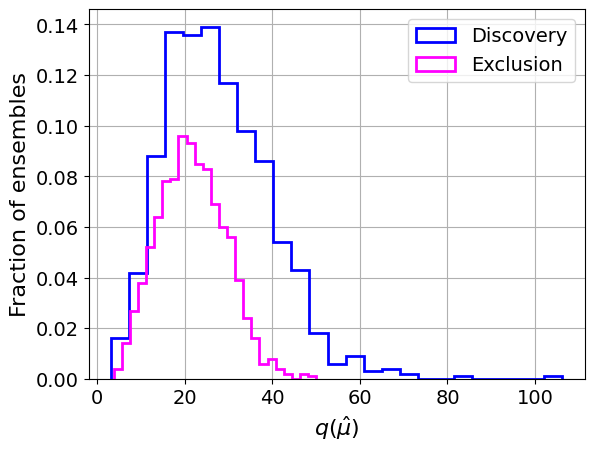


 Binned Likelihood:
Z_dis =  5.153780178464294  +-  1.1615963807613547
Z_exc =  4.632647635147103  +-  0.8188792286985377


------------------------------------------

BP:  63
B_expected:  2414.238598972644
S_expected:  55.152825454310396

 Asimov datasets:
Z_asim_dis =  6.20734384097527
Z_asim_exc =  5.423435722451353



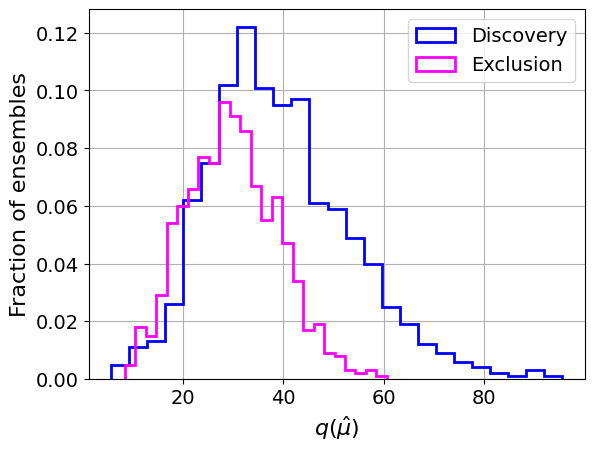


 Binned Likelihood:
Z_dis =  6.114513257735985  +-  1.1408068267756508
Z_exc =  5.423127636455667  +-  0.8338957881434567


------------------------------------------

BP:  219
B_expected:  2414.238598972644
S_expected:  49.781043656981105

 Asimov datasets:
Z_asim_dis =  5.6933891214432455
Z_asim_exc =  5.011152704026643



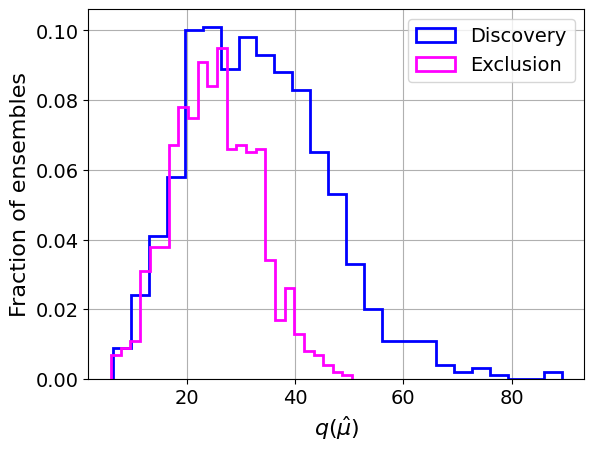


 Binned Likelihood:
Z_dis =  5.68249499664286  +-  1.1179468685072877
Z_exc =  4.9911346125532505  +-  0.7834427661703435


------------------------------------------

BP:  220
B_expected:  2414.238598972644
S_expected:  44.757189118164604

 Asimov datasets:
Z_asim_dis =  5.200623821214475
Z_asim_exc =  4.628119976165323



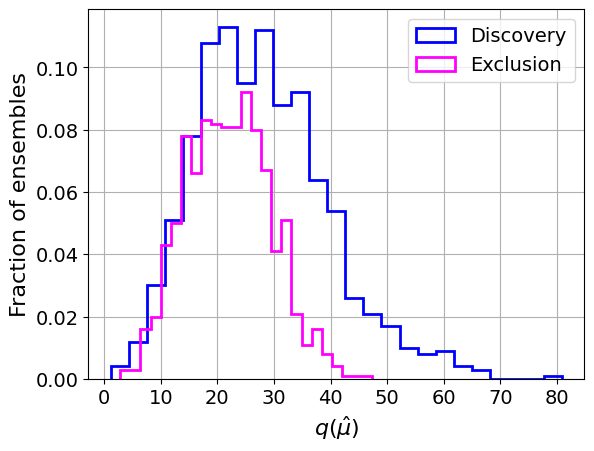


 Binned Likelihood:
Z_dis =  5.188402126388634  +-  1.1257064387993596
Z_exc =  4.681579281775027  +-  0.7931238169223935


------------------------------------------

BP:  586
B_expected:  2414.238598972644
S_expected:  43.3166418425058

 Asimov datasets:
Z_asim_dis =  4.795137201647581
Z_asim_exc =  4.3097729604831345



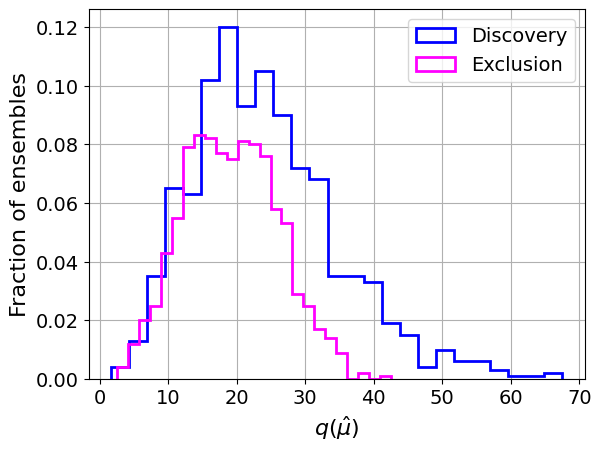


 Binned Likelihood:
Z_dis =  4.77595373727323  +-  1.107312532308383
Z_exc =  4.356717516993938  +-  0.7854739881260399


------------------------------------------

BP:  635
B_expected:  2414.238598972644
S_expected:  38.346320817831

 Asimov datasets:
Z_asim_dis =  4.382033388235026
Z_asim_exc =  3.960261188875418



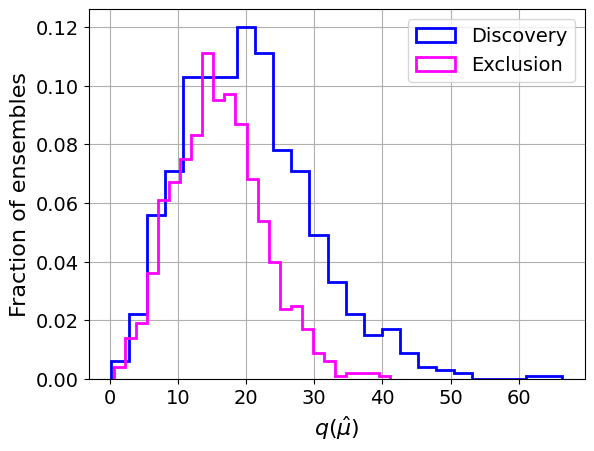


 Binned Likelihood:
Z_dis =  4.425341542880169  +-  1.0661848417676185
Z_exc =  3.9791682237368207  +-  0.8111185800654142


------------------------------------------

BP:  658
B_expected:  2414.238598972644
S_expected:  31.6976230577865

 Asimov datasets:
Z_asim_dis =  3.555209670488972
Z_asim_exc =  3.273150624471323



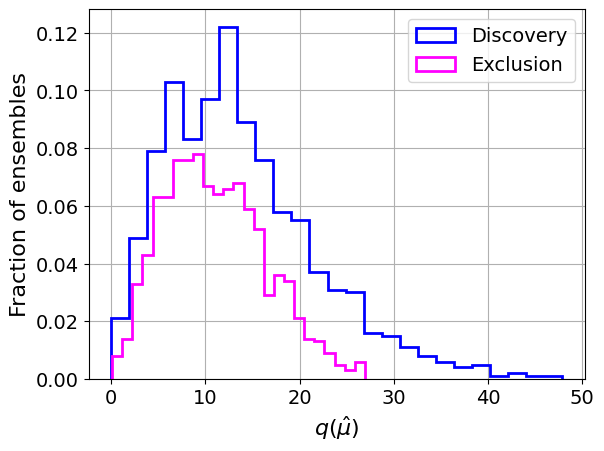


 Binned Likelihood:
Z_dis =  3.536962186014876  +-  1.1324580366063979
Z_exc =  3.246889849003431  +-  0.8221020523277104


------------------------------------------

BP:  673
B_expected:  2414.238598972644
S_expected:  39.170150265650996

 Asimov datasets:
Z_asim_dis =  4.462353509066071
Z_asim_exc =  4.03085790107317



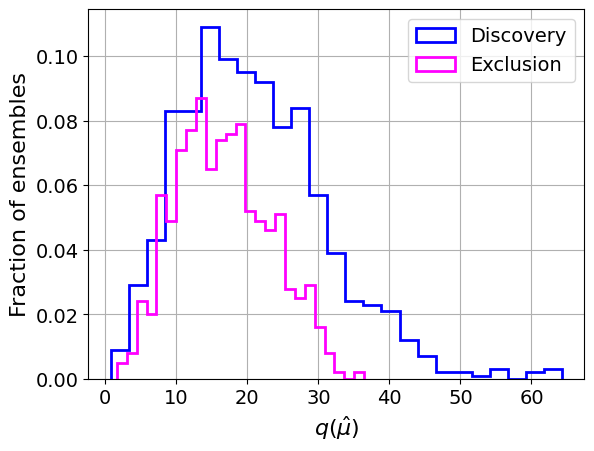


 Binned Likelihood:
Z_dis =  4.468580555179769  +-  1.1305705686114096
Z_exc =  4.031268382128905  +-  0.8147482541668629


------------------------------------------

BP:  678
B_expected:  2414.238598972644
S_expected:  36.2340682244019

 Asimov datasets:
Z_asim_dis =  4.161361476074226
Z_asim_exc =  3.7717969597931678



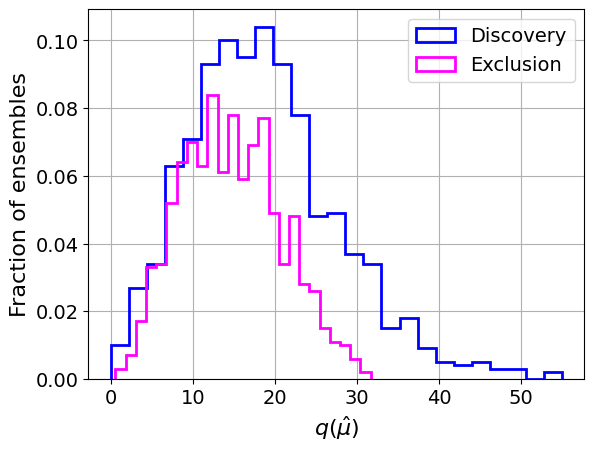


 Binned Likelihood:
Z_dis =  4.210374705358256  +-  1.071133449417798
Z_exc =  3.7857908027822162  +-  0.802208890271075


------------------------------------------

BP:  684
B_expected:  2414.238598972644
S_expected:  39.5540163354663

 Asimov datasets:
Z_asim_dis =  4.681223518612368
Z_asim_exc =  4.196064295482826



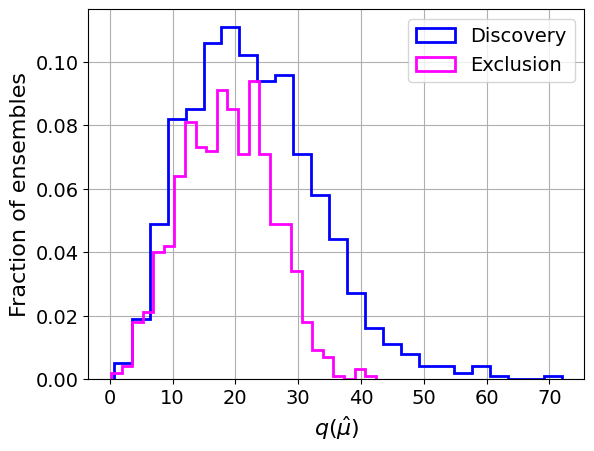


 Binned Likelihood:
Z_dis =  4.678866083743569  +-  1.1081563027413992
Z_exc =  4.307048446717369  +-  0.819717458167873


------------------------------------------

BP:  685
B_expected:  2414.238598972644
S_expected:  32.0820355059891

 Asimov datasets:
Z_asim_dis =  3.6024906425334424
Z_asim_exc =  3.3139301159648316



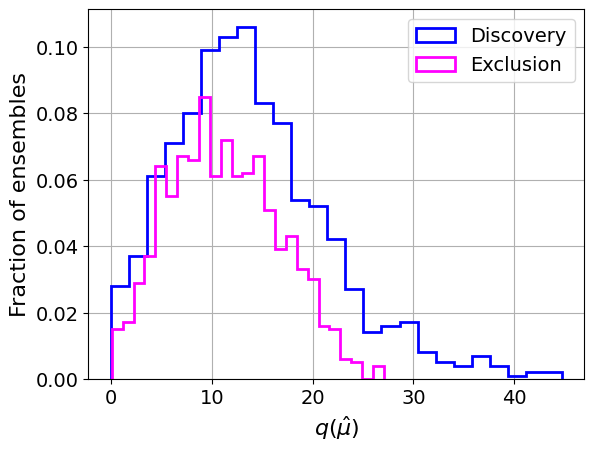


 Binned Likelihood:
Z_dis =  3.581600631255635  +-  1.079428444229482
Z_exc =  3.312125718875009  +-  0.8179847893255162


------------------------------------------

BP:  728
B_expected:  2414.238598972644
S_expected:  27.5731701069489

 Asimov datasets:
Z_asim_dis =  3.0543452385939354
Z_asim_exc =  2.842192497535974



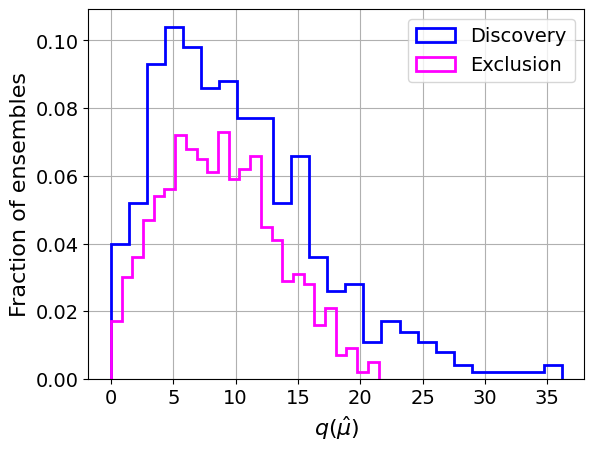


 Binned Likelihood:
Z_dis =  3.0143105468760765  +-  1.0815349339279021
Z_exc =  2.9142863734549036  +-  0.778570370144432


------------------------------------------

BP:  732
B_expected:  2414.238598972644
S_expected:  27.6409104154485

 Asimov datasets:
Z_asim_dis =  3.19857544945733
Z_asim_exc =  2.9617897999794396



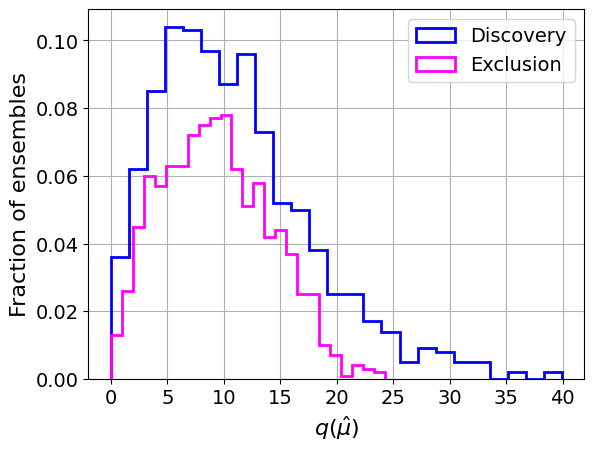


 Binned Likelihood:
Z_dis =  3.12795178507331  +-  1.0906542687046885
Z_exc =  3.0090422638016507  +-  0.7866809161832365


------------------------------------------

BP:  752
B_expected:  2414.238598972644
S_expected:  27.2018347808307

 Asimov datasets:
Z_asim_dis =  3.035441313356942
Z_asim_exc =  2.8289948524668964



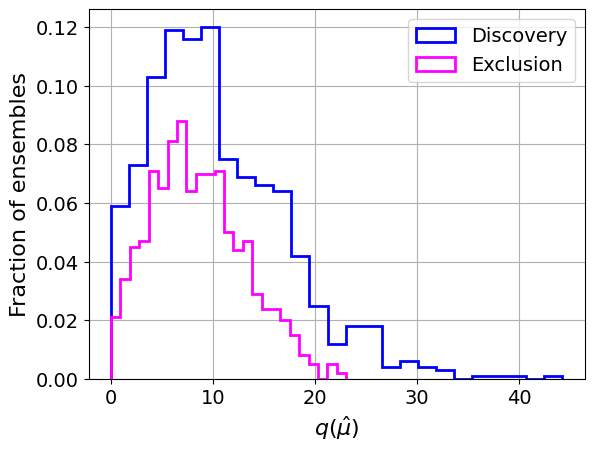


 Binned Likelihood:
Z_dis =  3.0403498006642553  +-  1.1031588587147214
Z_exc =  2.8401681921130297  +-  0.8030883790379209


------------------------------------------

BP:  754
B_expected:  2414.238598972644
S_expected:  34.2380098209927

 Asimov datasets:
Z_asim_dis =  3.9128968165307203
Z_asim_exc =  3.569340681004843



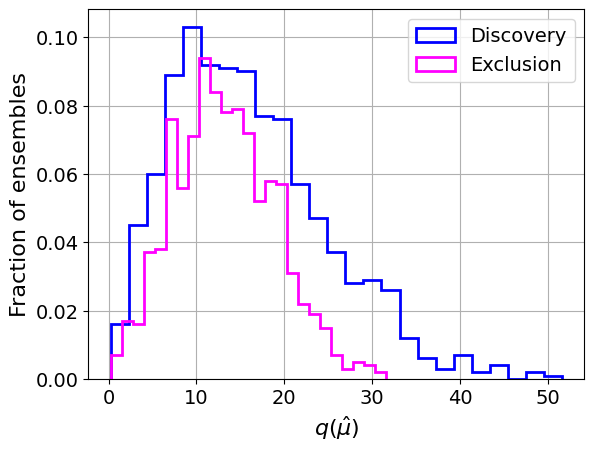


 Binned Likelihood:
Z_dis =  3.8434478631655096  +-  1.1369690146045492
Z_exc =  3.597652389278937  +-  0.7956140102591112


------------------------------------------

BP:  758
B_expected:  2414.238598972644
S_expected:  34.921997499465

 Asimov datasets:
Z_asim_dis =  3.9638723039019554
Z_asim_exc =  3.6127316587455467



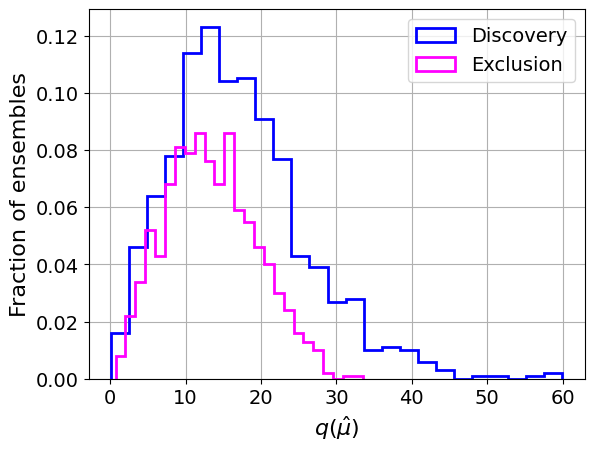


 Binned Likelihood:
Z_dis =  3.977653406073625  +-  1.1228258946517136
Z_exc =  3.6134377607674946  +-  0.8275697170807449


------------------------------------------

BP:  763
B_expected:  2414.238598972644
S_expected:  35.879315818069195

 Asimov datasets:
Z_asim_dis =  3.8095581225796447
Z_asim_exc =  3.5011129075191696



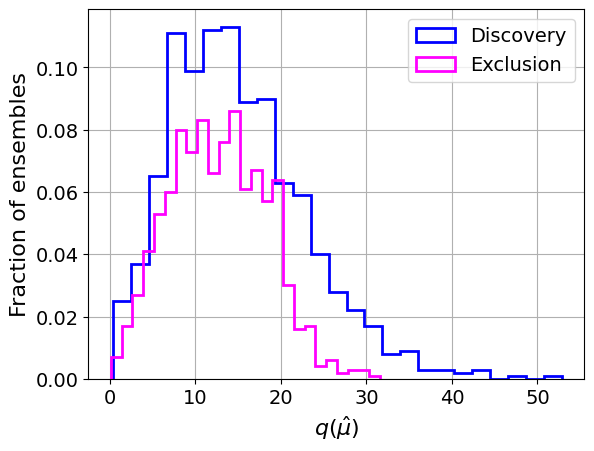


 Binned Likelihood:
Z_dis =  3.7247984200741384  +-  1.0525151272509445
Z_exc =  3.553379501446655  +-  0.7908504159435198


------------------------------------------

BP:  765
B_expected:  2414.238598972644
S_expected:  31.9527537465306

 Asimov datasets:
Z_asim_dis =  3.4950965498937836
Z_asim_exc =  3.225245997247699



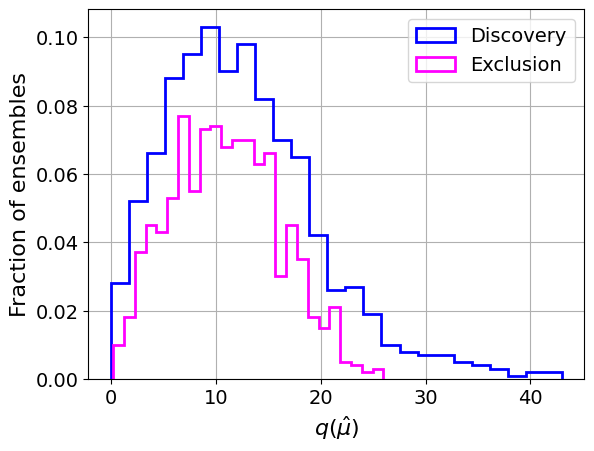


 Binned Likelihood:
Z_dis =  3.3906600777300175  +-  1.0731874969139545
Z_exc =  3.269520361624527  +-  0.7791304237467063


------------------------------------------

BP:  787
B_expected:  2414.238598972644
S_expected:  39.4394626446975

 Asimov datasets:
Z_asim_dis =  4.706991404415773
Z_asim_exc =  4.210189927979297



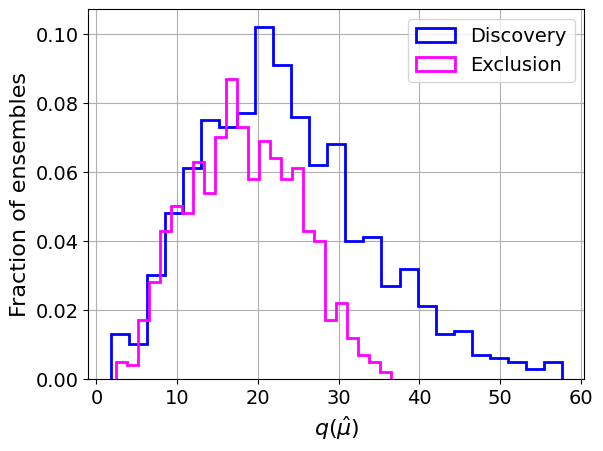


 Binned Likelihood:
Z_dis =  4.701870628112145  +-  1.1105442465158004
Z_exc =  4.2366842545892505  +-  0.7842319785050177


------------------------------------------

BP:  791
B_expected:  2414.238598972644
S_expected:  26.2838468732091

 Asimov datasets:
Z_asim_dis =  2.959595890182273
Z_asim_exc =  2.7605587488089673



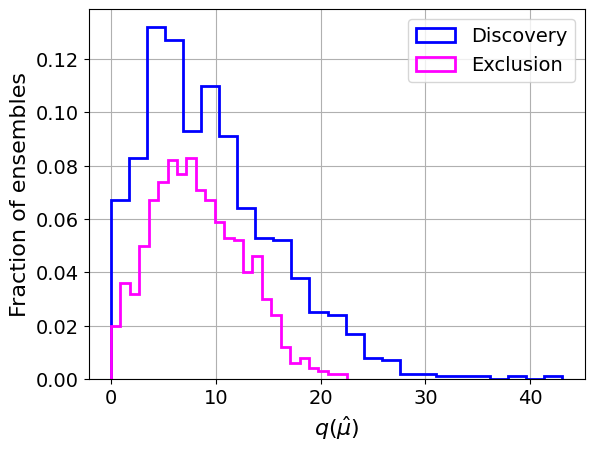


 Binned Likelihood:
Z_dis =  2.9238198951460332  +-  1.0837155620872445
Z_exc =  2.7842717078204466  +-  0.7742218838741017


------------------------------------------

BP:  826
B_expected:  2414.238598972644
S_expected:  28.8561457371516

 Asimov datasets:
Z_asim_dis =  3.297435896967913
Z_asim_exc =  3.049165220579201



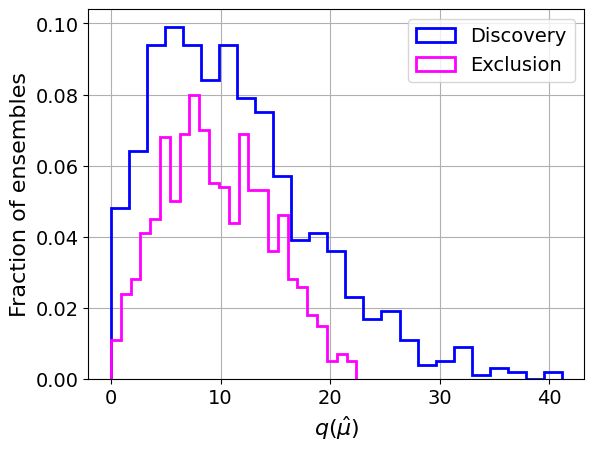


 Binned Likelihood:
Z_dis =  3.1876740372899754  +-  1.1449535559636286
Z_exc =  3.0361890996253624  +-  0.793638171189333


------------------------------------------

BP:  841
B_expected:  2414.238598972644
S_expected:  27.080951804182202

 Asimov datasets:
Z_asim_dis =  3.11687210016503
Z_asim_exc =  2.8896923218356845



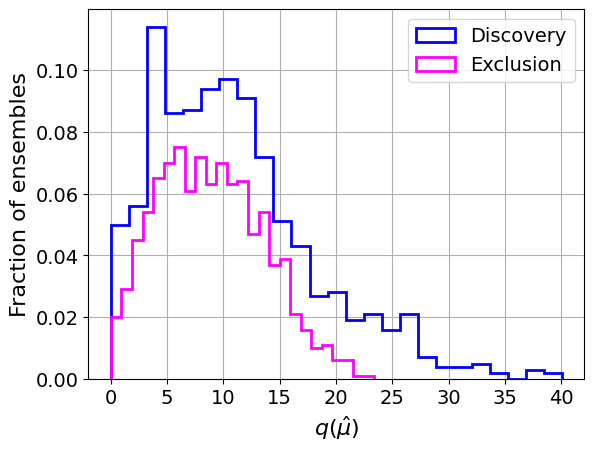


 Binned Likelihood:
Z_dis =  3.1528566575617174  +-  1.1355613078330753
Z_exc =  2.9230563167464494  +-  0.7986892681311936


------------------------------------------

BP:  850
B_expected:  2414.238598972644
S_expected:  34.3532142741135

 Asimov datasets:
Z_asim_dis =  3.9701729325958497
Z_asim_exc =  3.6151090232261183



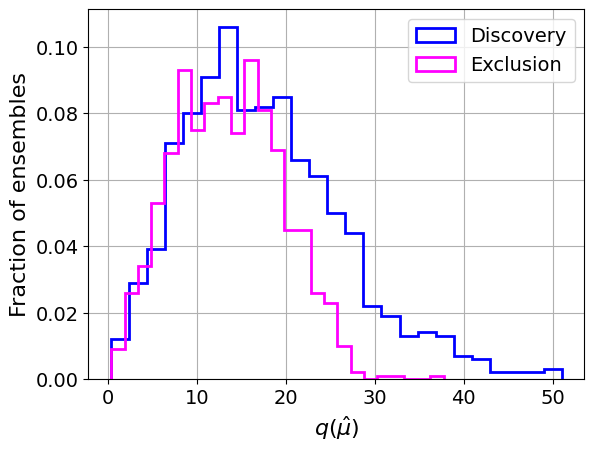


 Binned Likelihood:
Z_dis =  4.032685780194923  +-  1.1107214814967343
Z_exc =  3.678404262233647  +-  0.8129646302254732


------------------------------------------

BP:  855
B_expected:  2414.238598972644
S_expected:  23.939143994349

 Asimov datasets:
Z_asim_dis =  2.747229967205229
Z_asim_exc =  2.566154765593054



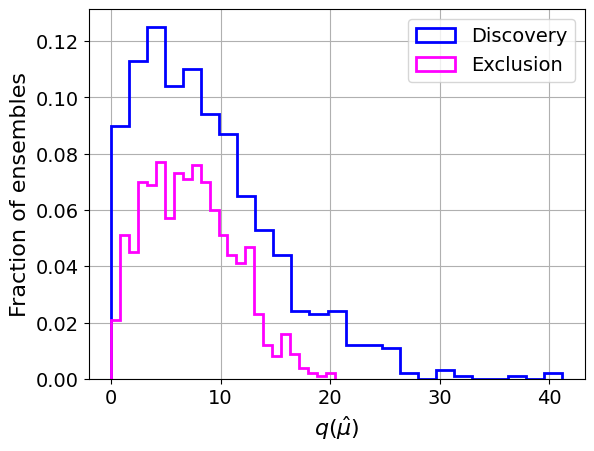


 Binned Likelihood:
Z_dis =  2.7760150124745775  +-  1.1322282793611391
Z_exc =  2.6303696274744888  +-  0.7624470246632316


------------------------------------------

BP:  872
B_expected:  2414.238598972644
S_expected:  24.2376537504696

 Asimov datasets:
Z_asim_dis =  2.7762233792796915
Z_asim_exc =  2.59730352652009



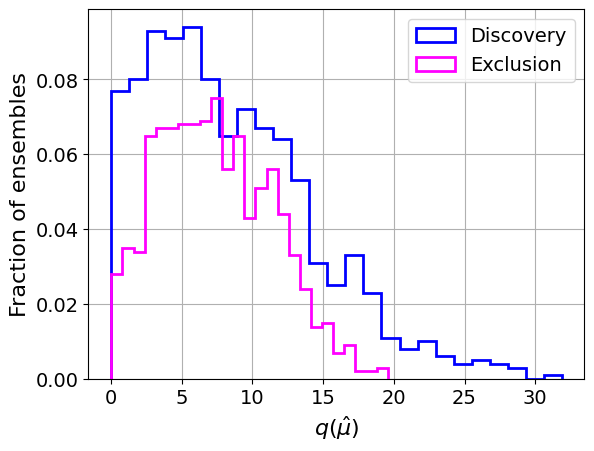


 Binned Likelihood:
Z_dis =  2.7090356071149615  +-  1.0949634661544583
Z_exc =  2.660080244394009  +-  0.7507893628574095


------------------------------------------

BP:  875
B_expected:  2414.238598972644
S_expected:  24.4625534608248

 Asimov datasets:
Z_asim_dis =  2.7336189467123657
Z_asim_exc =  2.562038194565277



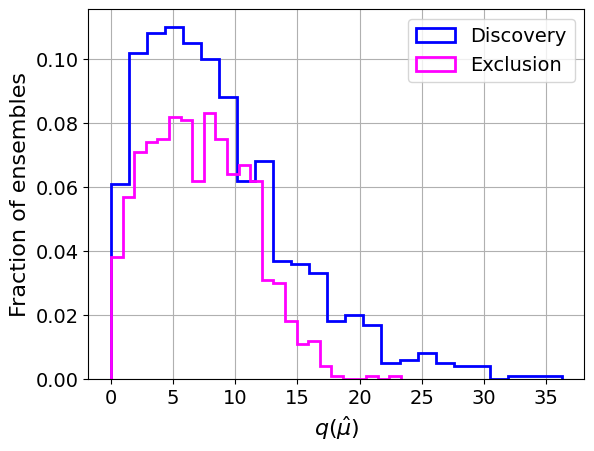


 Binned Likelihood:
Z_dis =  2.718382009731931  +-  1.1167054321883163
Z_exc =  2.6172222824757574  +-  0.7647626240496759


------------------------------------------

BP:  881
B_expected:  2414.238598972644
S_expected:  24.537474068663702

 Asimov datasets:
Z_asim_dis =  2.7827748378336277
Z_asim_exc =  2.5982615705193126



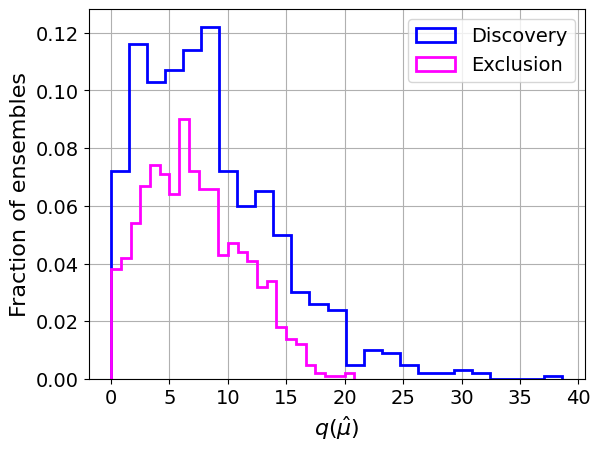


 Binned Likelihood:
Z_dis =  2.744194127380519  +-  1.0630313224680188
Z_exc =  2.5811355578462503  +-  0.7971192839574607


------------------------------------------

BP:  1017
B_expected:  2414.238598972644
S_expected:  23.8645978215969

 Asimov datasets:
Z_asim_dis =  2.6263647950984854
Z_asim_exc =  2.4665455133989065



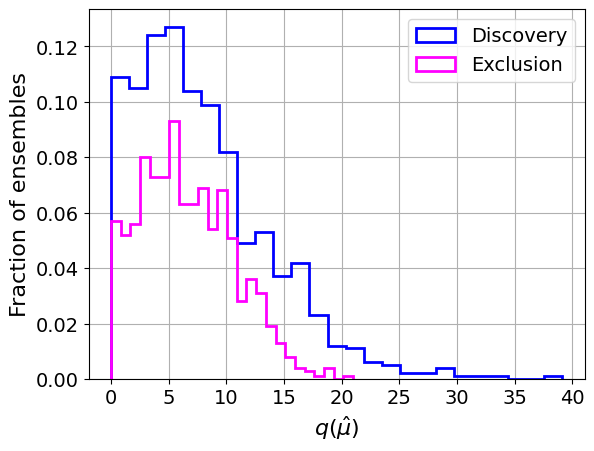


 Binned Likelihood:
Z_dis =  2.5971859211520103  +-  1.1174830680656664
Z_exc =  2.4632370450239276  +-  0.8088292828583618


------------------------------------------

BP:  1035
B_expected:  2414.238598972644
S_expected:  23.7046856345805

 Asimov datasets:
Z_asim_dis =  2.765275976111623
Z_asim_exc =  2.5818738684122478



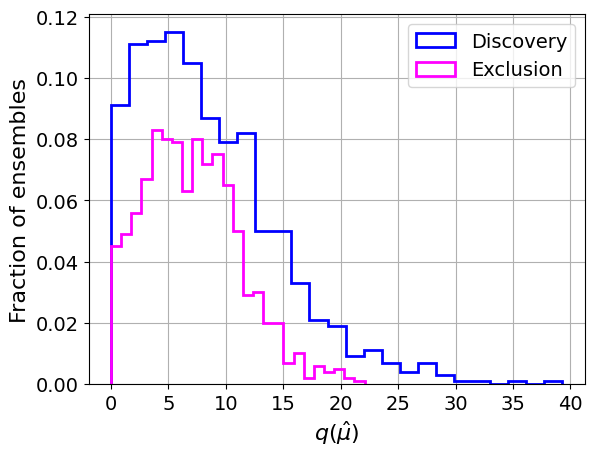


 Binned Likelihood:
Z_dis =  2.7073563697256464  +-  1.1295212034540514
Z_exc =  2.5998805127532556  +-  0.7972373455987942


------------------------------------------

BP:  1036
B_expected:  2414.238598972644
S_expected:  24.2159467425672

 Asimov datasets:
Z_asim_dis =  2.825416629035767
Z_asim_exc =  2.6351101718303824



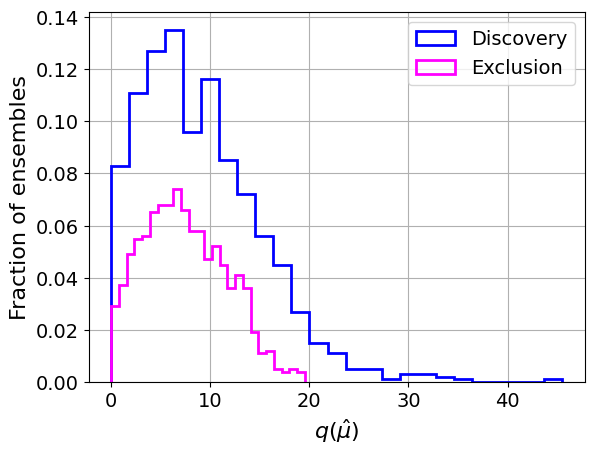


 Binned Likelihood:
Z_dis =  2.8257750283757788  +-  1.0794587104338709
Z_exc =  2.65276620723561  +-  0.7790550132503195


------------------------------------------

BP:  1087
B_expected:  2414.238598972644
S_expected:  24.1808841294582

 Asimov datasets:
Z_asim_dis =  2.805921666910502
Z_asim_exc =  2.619130237441036



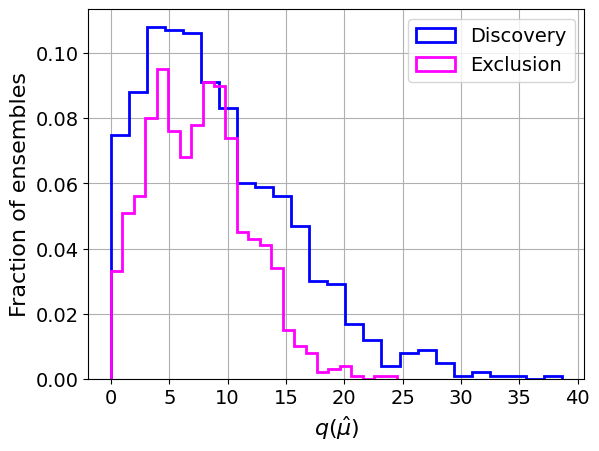


 Binned Likelihood:
Z_dis =  2.82027692753166  +-  1.130392564353998
Z_exc =  2.727860187940629  +-  0.7623740535683281


------------------------------------------

BP:  1103
B_expected:  2414.238598972644
S_expected:  24.6650299760703

 Asimov datasets:
Z_asim_dis =  2.763712322075118
Z_asim_exc =  2.5854936916324185



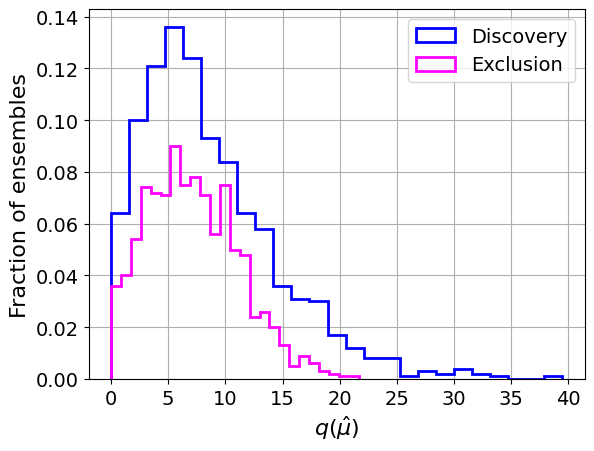


 Binned Likelihood:
Z_dis =  2.6949638696035825  +-  1.0999996670802201
Z_exc =  2.6152841167436294  +-  0.7655628974812108


------------------------------------------

BP:  1104
B_expected:  2414.238598972644
S_expected:  24.499352169771

 Asimov datasets:
Z_asim_dis =  2.7211917664905663
Z_asim_exc =  2.5517667284741297



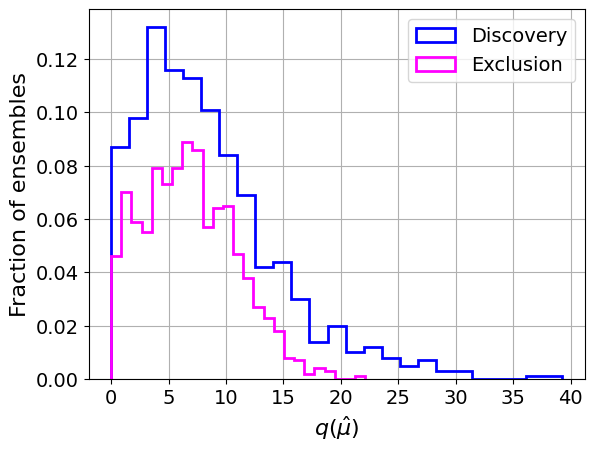


 Binned Likelihood:
Z_dis =  2.674066141688114  +-  1.135379742538932
Z_exc =  2.5623742660652993  +-  0.7793933285405565


------------------------------------------



In [29]:
Z_asim_dis = []
Z_asim_exc = []


Z_dis = {}
Z_exc = {}

Z_dis_std = {}
Z_exc_std = {}


for bp_it in BP_used:

    # Filtramos las predicciones solo de este BP
    y_pred_S_bp = y_pred[BP_test == f'BP{bp_it}']
    n_S_test_bp = len(y_pred_S_bp)

    # Obtenemos su S_expected
    S_bp = S_expected_all[f'BP{bp_it}']

    print('BP: ', bp_it)
    print('B_expected: ', B_expected)
    print('S_expected: ', S_bp)


    ###################
    # ASIMOV EXPECTED #
    ###################

    # SLQ PDF
    hist, _ = np.histogram(y_pred_S_bp, bins=N_bins, range=(0,1))
    S_template = hist / (len(y_pred_S_bp) / S_bp)


    Z_asim_dis_it = Z_asimov_dis(S_template, B_template)
    Z_asim_exc_it = Z_asimov_exc(S_template, B_template)


    Z_asim_dis.append(Z_asim_dis_it)
    Z_asim_exc.append(Z_asim_exc_it)


    print('\n Asimov datasets:')
    print('Z_asim_dis = ', Z_asim_dis_it)
    print('Z_asim_exc = ', Z_asim_exc_it)
    print()



    #####################
    # BINNED LIKELIHOOD #
    #####################

    q_dis = []
    q_exc = []


    for pexp_it in range(n_pseudo):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_bp)


        # pseudo experiment (DISCOVERY: SM vs SM+Signal)
        scoresA_pseudo = generate_pseudo_1output_dis( y_pred_B, y_pred_S_bp, N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo, bins=N_bins, range=(0,1))
        N_pseudo = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( y_pred_B, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist



        # DISCOVERY (mu_hat=1 idedally)
        mu_hat_dis = fsolve(lambda x: f_mu_hat(x, N_pseudo, S_template, B_template),1)[0] # search around mu=1 for discovery

        q_dis_it = q0(N_pseudo, S_template, B_template, mu_hat_dis)
        q_dis.append(q_dis_it)


        # EXCLUSION (mu_hat=0 idedally)
        mu_hat_exc = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_it = q1(N_pseudo_EXC, S_template, B_template, mu_hat_exc)
        q_exc.append(q_exc_it)






    # Histogram of q_muhats
    weights = np.ones_like(q_dis)/float(len(q_dis))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis, 25, weights=weights, histtype='step', color='blue', linewidth=2, label='Discovery')

    weights = np.ones_like(q_exc)/float(len(q_exc))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='Exclusion')
    #plt.xlim(0,1)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("$q(\hat{\mu})$",fontsize=16)
    plt.ylabel("Fraction of ensembles",fontsize=16)
    plt.grid()
    plt.legend(fontsize=14)
    plt.show()




    Z_dis_it = np.sqrt(np.median(q_dis))
    Z_dis_std_it = np.std(q_dis) / (2. * Z_dis_it)

    Z_exc_it = np.sqrt(np.median(q_exc))
    Z_exc_std_it = np.std(q_exc) / (2. * Z_exc_it)


    Z_dis[f'BP{bp_it}'] = Z_dis_it
    Z_dis_std[f'BP{bp_it}'] = Z_dis_std_it
    Z_exc[f'BP{bp_it}'] = Z_exc_it
    Z_exc_std[f'BP{bp_it}'] = Z_exc_std_it


    print('\n Binned Likelihood:')
    print('Z_dis = ', Z_dis_it, ' +- ', Z_dis_std_it)
    print('Z_exc = ', Z_exc_it, ' +- ', Z_exc_std_it)
    print()




    print('\n------------------------------------------\n')

--- Evaluando di higggs SM ---
B_expected:  2414.238598972644
S_expected:  24.459737661136796

Asimov datasets (X0):
Z_asim_dis =  2.766592115026458
Z_asim_exc =  2.587399861903832



<>:84: SyntaxWarning: invalid escape sequence '\h'
<>:84: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_4139/1712032271.py:84: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$q(\hat{\mu})$", fontsize=16)


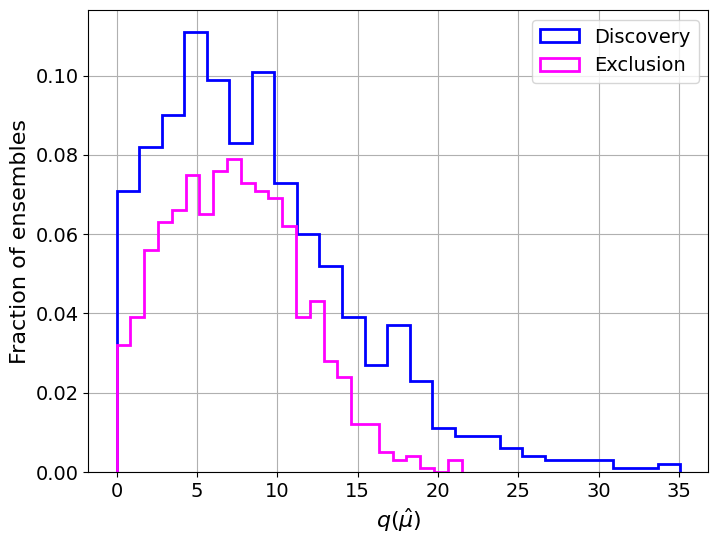


Binned Likelihood Final para X0:
Z_dis = 2.774 +- 1.095
Z_exc = 2.685 +- 0.748
------------------------------------------



In [30]:
# ==========================================

# Prediction
y_pred_0 = classifier_hh.predict_proba(X0_scaled)[:, 1]
n_S0 = len(y_pred_0)







print('--- Evaluando di higggs SM ---')
print('B_expected: ', B_expected)
print('S_expected: ', S_expected_BP0)

# SM PDF
hist_SM, edges = np.histogram(y_pred_B, bins=N_bins, range=(0, 1))
B_template = hist_SM / (len(y_pred_B) / B_expected)

# X0 PDF
hist_S0, _ = np.histogram(y_pred_0, bins=N_bins, range=(0, 1))
S_template = hist_S0 / (n_S0 / S_expected_BP0)


# =======
# ASIMOV
# =======
Z_asim_dis_X0 = Z_asimov_dis(S_template, B_template)
Z_asim_exc_X0 = Z_asimov_exc(S_template, B_template)

print('\nAsimov datasets (X0):')
print('Z_asim_dis = ', Z_asim_dis_X0)
print('Z_asim_exc = ', Z_asim_exc_X0)
print()


# ==================
# BINNED LIKELIHOOD
# ==================
q_dis_X0 = []
q_exc_X0 = []

for pexp_it in range(n_pseudo):

    # Poisson
    N_B = np.random.poisson(B_expected)
    N_S = np.random.poisson(S_expected_BP0)

    # Pseudoexperimento para DESCUBRIMIENTO (Fondo + Señal X0)
    scoresA_pseudo = generate_pseudo_1output_dis(y_pred_B, y_pred_0, N_B, N_S)
    hist, _ = np.histogram(scoresA_pseudo, bins=N_bins, range=(0, 1))
    N_pseudo = hist

    # Pseudoexperimento para EXCLUSIÓN (Solo Fondo)
    scoresA_pseudo_EXC = generate_pseudo_1output_exc(y_pred_B, N_B)
    hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0, 1))
    N_pseudo_EXC = hist

    # AJUSTE DE VEROSIMILITUD (Likelihood Fit)

    # Descubrimiento (Buscamos mu_hat alrededor de 1)
    mu_hat_dis = fsolve(lambda x: f_mu_hat(x, N_pseudo, S_template, B_template), 1)[0]
    q_dis_it = q0(N_pseudo, S_template, B_template, mu_hat_dis)
    q_dis_X0.append(q_dis_it)

    # Exclusión (Buscamos mu_hat alrededor de 0)
    mu_hat_exc = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template, B_template), 0)[0]
    q_exc_it = q1(N_pseudo_EXC, S_template, B_template, mu_hat_exc)
    q_exc_X0.append(q_exc_it)



# Graficar la distribución de los q_muhats para X0
plt.figure(figsize=(8, 6))
weights_dis = np.ones_like(q_dis_X0) / float(len(q_dis_X0))
plt.hist(q_dis_X0, 25, weights=weights_dis, histtype='step', color='blue', linewidth=2, label='Discovery')

weights_exc = np.ones_like(q_exc_X0) / float(len(q_exc_X0))
plt.hist(q_exc_X0, 25, weights=weights_exc, histtype='step', color='magenta', linewidth=2, label='Exclusion')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("$q(\hat{\mu})$", fontsize=16)
plt.ylabel("Fraction of ensembles", fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.show()

# Cálculo de las significancias Z
Z_dis_BP0 = np.sqrt(np.median(q_dis_X0))
Z_dis_std_BP0 = np.std(q_dis_X0) / (2. * Z_dis_BP0)

Z_exc_BP0 = np.sqrt(np.median(q_exc_X0))
Z_exc_std_BP0 = np.std(q_exc_X0) / (2. * Z_exc_BP0)

print('\nBinned Likelihood Final para X0:')
print(f'Z_dis = {Z_dis_BP0:.3f} +- {Z_dis_std_BP0:.3f}')
print(f'Z_exc = {Z_exc_BP0:.3f} +- {Z_exc_std_BP0:.3f}')
print('------------------------------------------\n')

### Compute S_predicted

Binned likelihood fit


f(x)=μS pS(x)+μB pB(x)


donde:

pS(x) = pdf del score para señal

pB(x) = pdf del score para background

μS, μB = yields a ajustar



maximizamos:

L(μS,μB)= Prod_i=1^N ( μS pS(xi) + μB pB (xi )) e^−(μS+μB)

eventos esperados en el bin i:

λi = μS pS,i + μB pB,i



Likelihood binned:

log L = Sum_i ( ni log(λi) − λi )

In [31]:
scores_S = y_pred[y_test == 1]
scores_B = y_pred[y_test == 0]

In [32]:
bins = np.linspace(0, 1, 30)

# normalized histograms of pure signal and pure background
hist_B, _ = np.histogram(scores_B, bins=bins, density=True)
hist_S, _ = np.histogram(scores_S, bins=bins, density=True) # the signal pdf is a generic (mixture of all) to be general


bin_width = bins[1] - bins[0]

pS = hist_S * bin_width
pB = hist_B * bin_width

In [33]:

n_pseudo = 1000


# to save
S_mean_fit = {}
S_std_fit  = {}
Z_fit = {}



for bp_it in BP_used:
    print('\n----------------')

    S_bp = S_expected_all[f'BP{bp_it}']
    print('S_expected = ', S_bp)

    S_mean_fit[f'BP{bp_it}'] = []
    S_std_fit[f'BP{bp_it}']  = []
    Z_fit[f'BP{bp_it}'] = []


    muS_fits = []
    muB_fits = []

    for n_it in range(n_pseudo):

        # 1) pseudo experiment
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_bp)

        sample_B = np.random.choice(scores_B, N_B, replace=True)
        sample_S = np.random.choice(scores_S, N_S, replace=True)

        data_scores = np.concatenate([sample_B, sample_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_bp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits.append(muS_fit)
        muB_fits.append(muB_fit)


    mean_muB = np.mean(muB_fits)

    mean_muS = np.mean(muS_fits)
    std_muS  = np.std(muS_fits)

    S_mean_fit[f'BP{bp_it}'].append(mean_muS)
    S_std_fit[f'BP{bp_it}'].append(std_muS)


    # significance
    logL_hat = -neg_logL([mean_muS, mean_muB])
    logL_null = -neg_logL([0, mean_muB])

    q0 = -2 * (logL_null - logL_hat)

    Z = np.sqrt(q0)

    Z_fit[f'BP{bp_it}'].append(Z)

    print("S =", mean_muS, "+-", std_muS)
    print("Z =", Z)
    print('')


----------------
S_expected =  63.908347098737096
S = 63.831029102974895 +- 11.89755574699532
Z = 6.459871036702778


----------------
S_expected =  60.585012455721
S = 60.57064250251587 +- 11.82022359318962
Z = 5.752802055780684


----------------
S_expected =  45.6197200384509
S = 45.481461536679724 +- 10.847350423702085
Z = 4.257900519553452


----------------
S_expected =  55.152825454310396
S = 55.22609981360758 +- 12.04966638538937
Z = 6.313800872585221


----------------
S_expected =  49.781043656981105
S = 49.978720566421806 +- 11.602620746283645
Z = 4.066139465791467


----------------
S_expected =  44.757189118164604
S = 45.01458752558237 +- 11.075903909376047
Z = 2.854210425558584


----------------
S_expected =  43.3166418425058
S = 43.87786982007949 +- 10.571274568767022
Z = 5.3273008248791145


----------------
S_expected =  38.346320817831
S = 38.16263798451483 +- 10.603114306600508
Z = 3.323070210051456


----------------
S_expected =  31.6976230577865
S = 31.404310869

/tmp/ipykernel_4139/4145212129.py:75: RuntimeWarning: invalid value encountered in sqrt
  Z = np.sqrt(q0)


S = 25.06976937782453 +- 9.87350044866122
Z = nan


----------------
S_expected =  24.499352169771
S = 24.675118437455442 +- 9.543304875589959
Z = 4.5104631327542



In [34]:
print('--- Evaluando di higggs SM ---')
print('B_expected: ', B_expected)
print('S_expected: ', S_expected_BP0)


# Prediction
y_pred_0 = classifier_hh.predict_proba(X0_scaled)[:, 1]


muS_fits = []
muB_fits = []

for n_it in range(n_pseudo):

    # 1) pseudo experiment
    N_B = np.random.poisson(B_expected)
    N_S = np.random.poisson(S_expected_BP0)

    sample_B = np.random.choice(scores_B, N_B, replace=True)
    sample_S = np.random.choice(y_pred_0, N_S, replace=True)

    data_scores = np.concatenate([sample_B, sample_S])

    hist_data, _ = np.histogram(data_scores, bins=bins)

    # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
    def neg_logL(params):
        mu_S, mu_B = params

        lambda_i = mu_S * pS + mu_B * pB
        lambda_i = np.clip(lambda_i, 1e-10, None)

        return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

    # 3) Minimizar
    result = minimize(
        neg_logL,
        x0=[S_expected_BP0, B_expected],
        bounds=[(0, None), (0, None)]
    )

    muS_fit, muB_fit = result.x

    muS_fits.append(muS_fit)
    muB_fits.append(muB_fit)


mean_muB = np.mean(muB_fits)

mean_muS = np.mean(muS_fits)
std_muS  = np.std(muS_fits)

S_mean_fit_BP0 = mean_muS
S_std_fit_BP0 = std_muS


# significance
logL_hat = -neg_logL([mean_muS, mean_muB])
logL_null = -neg_logL([0, mean_muB])

q0 = -2 * (logL_null - logL_hat)

Z = np.sqrt(q0)

Z_fit_BP0 = Z

print("S =", mean_muS, "+-", std_muS)
print("Z =", Z)
print('')

--- Evaluando di higggs SM ---
B_expected:  2414.238598972644
S_expected:  24.459737661136796
S = 23.86583525870424 +- 9.688115299838898
Z = 2.2299478434997067



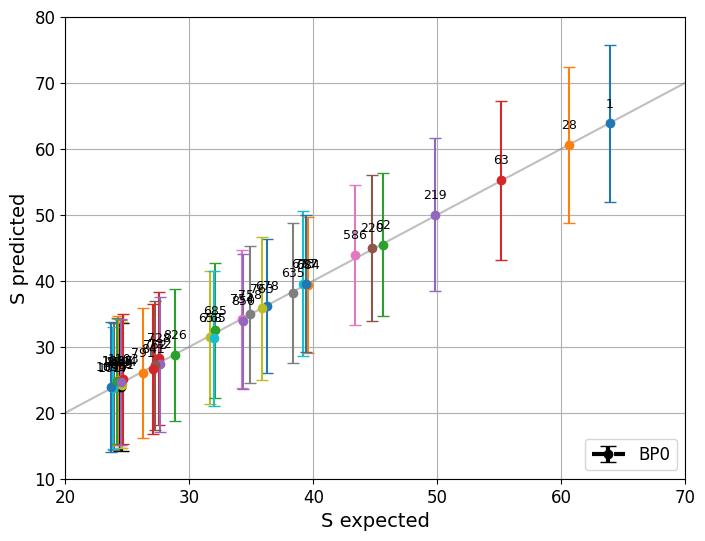

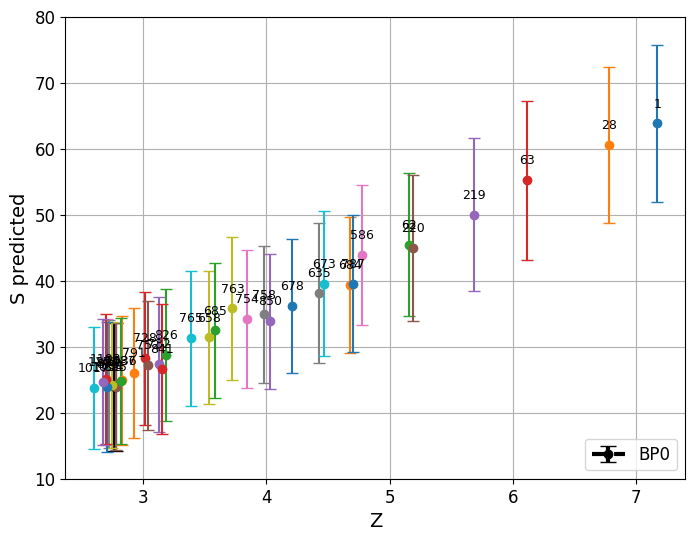

In [37]:
S_plot = np.linspace(20, 70, 100)


plt.figure(figsize=(8, 6))

plt.plot(S_plot, S_plot, color='gray', alpha=0.5)


plt.errorbar(S_expected_BP0, S_mean_fit_BP0, yerr=S_std_fit_BP0, fmt='o--', color='black', capsize=6,  linewidth=3, label='BP0')

for bp_it in BP_used:
    plt.errorbar(S_expected_all[f'BP{bp_it}'], S_mean_fit[f'BP{bp_it}'], yerr=S_std_fit[f'BP{bp_it}'], fmt='o-', capsize=4)

    # text
    plt.text(S_expected_all[f'BP{bp_it}'], S_mean_fit[f'BP{bp_it}'][0]+2, bp_it, fontsize=9, ha='center', va='bottom')

plt.ylim(10,80)
plt.xlim(20,70)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("S expected", fontsize=14)
plt.ylabel("S predicted", fontsize=14)
plt.grid()
plt.legend(fontsize=12, loc='lower right')
# plt.savefig(mainfolder + "saved-figures/AUC_vs_Z.pdf", bbox_inches='tight')
plt.show()




plt.figure(figsize=(8, 6))

plt.errorbar(Z_dis_BP0, S_mean_fit_BP0, yerr=S_std_fit_BP0, fmt='o--', color='black', capsize=6,  linewidth=3, label='BP0')

for bp_it in BP_used:
    # plt.errorbar(results[bp_it]['Zmax'], S_mean_fit[f'BP{bp_it}'], yerr=S_std_fit[f'BP{bp_it}'], fmt='o-', capsize=4)
    plt.errorbar(Z_dis[f'BP{bp_it}'], S_mean_fit[f'BP{bp_it}'], yerr=S_std_fit[f'BP{bp_it}'], fmt='o-', capsize=4)

    # text
    # plt.text(results[bp_it]['Zmax'], S_mean_fit[f'BP{bp_it}'][0]+2, bp_it, fontsize=9, ha='center', va='bottom')
    plt.text(Z_dis[f'BP{bp_it}'], S_mean_fit[f'BP{bp_it}'][0]+2, bp_it, fontsize=9, ha='center', va='bottom')

plt.ylim(10,80)
# plt.xlim(20,70)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Z", fontsize=14)
plt.ylabel("S predicted", fontsize=14)
plt.grid()
plt.legend(fontsize=12, loc='lower right')
# plt.savefig(mainfolder + "saved-figures/AUC_vs_Z.pdf", bbox_inches='tight')
plt.show()

In [36]:
# COMPUTE THE ONES THAT OVERLAP WITH BP0

# limits of BP0 considering its error
S_BP0_low = S_mean_fit_BP0 - S_std_fit_BP0
S_BP0_high = S_mean_fit_BP0 + S_std_fit_BP0


BP_overlap = []

for bp_it in BP_used:
    key = f'BP{bp_it}'

    # limits of each BP
    S_BP_low = S_mean_fit[f'BP{bp_it}'][0] - S_std_fit[f'BP{bp_it}'][0]
    S_BP_high = S_mean_fit[f'BP{bp_it}'][0] + S_std_fit[f'BP{bp_it}'][0]

    # Check if they overlap
    overlap = np.any((S_BP_low <= S_BP0_high) & (S_BP_high >= S_BP0_low))

    if overlap:
        BP_overlap.append(bp_it)


print("# BP that overlap with BP0: ", len(BP_overlap))
print()
print(BP_overlap)


# BP that overlap with BP0:  29

[586, 635, 658, 673, 678, 684, 685, 728, 732, 752, 754, 758, 763, 765, 787, 791, 826, 841, 850, 855, 872, 875, 881, 1017, 1035, 1036, 1087, 1103, 1104]


63.90376886858499
24.456995153760634

63.89336380005748
24.454938273228514

63.85007871498301
24.44054010950367

63.61991859915439
24.339067336585707

62.89614203238045
23.981855750840722

61.36618075609467
23.137849105827144

59.02087830999284
21.757682268774072

55.99008994929832
19.97642372795744

52.72872527003408
17.975078970203878

49.45362590031352
15.925740333367498

46.37414181891023
13.924395575613936

43.55894647810582
12.104741931531048

41.051324962974746
10.449638730017824

38.81173801311246
9.01325049175345

36.83643980384905
7.716730129673291

35.10337158990618
6.625897820805213

33.55967562316409
5.659163970708427

32.177050117227914
4.872064353750191

30.94342519260576
4.158326809104265

29.79304081620372
3.596798423835281

28.706751661931175
3.0626951123279067

27.68122810785931
2.638292095866977

26.64113745784893
2.259826077956745

25.575242237890315
1.9314108196614537

24.424025456006074
1.6578457088893839

23.11257061879811
1.4350169845762948

21.657525835910437


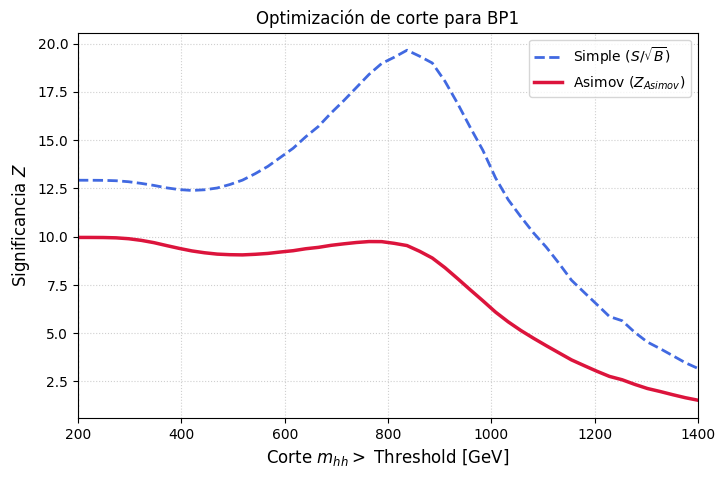

In [80]:
var_name = feats_label.index('m_hh')
BP_sel0 = 'BP0'
BP_sel1 = 'BP1'

datos_B = X_S0_all[BP_sel0][:, var_name]  # Fondo (BP_sel0)
datos_S = X_S_all[BP_sel1][:, var_name]   # Señal (BP_sel1)

# Número total de eventos físicos esperados (reemplaza con tus variables si tienen otro nombre)
N_esperados_B = S_expected_BP0
N_esperados_S = S_expected_all[BP_sel1]

# 2. Definir los candidatos a threshold (barrido de 200 a 1400 GeV)
thresholds = np.linspace(200, 1400, 50)

significancias_simple = []
significancias_asimov = []
thresholds_validos = []

for th in thresholds:
    # --- EFICIENCIA DE SELECCIÓN ---
    fraccion_S_pasan = np.sum(datos_S > th) / len(datos_S)
    fraccion_B_pasan = np.sum(datos_B > th) / len(datos_B)

    # --- EVENTOS FÍSICOS FINALES ---
    S = N_esperados_S * fraccion_S_pasan
    B = N_esperados_B * fraccion_B_pasan

    print(S)
    print(B)
    print()

    # Exigimos al menos un fondo y señal residuales para poder calcular
    if B > 1e-4 and S > 1e-4:
        # 1. Fórmula Simple (S / sqrt(B))
        Z_sim = S / np.sqrt(B)

        # 2. Fórmula de Asimov
        # Usamos np.log1p(x) que calcula ln(1 + x) de manera numéricamente más estable para valores pequeños
        Z_asi = np.sqrt(2 * ((S + B) * np.log1p(S / B) - S))

        significancias_simple.append(Z_sim)
        significancias_asimov.append(Z_asi)
        thresholds_validos.append(th)
    else:
        # Detenemos si ya no quedan eventos suficientes para un cálculo con sentido físico
        break

# Convertir a arrays
significancias_simple = np.array(significancias_simple)
significancias_asimov = np.array(significancias_asimov)
thresholds_validos = np.array(thresholds_validos)

# 3. Encontrar el óptimo usando ASIMOV (que es la métrica rigurosa)
idx_max = np.argmax(significancias_asimov)
best_threshold = thresholds_validos[idx_max]
best_Z_asimov = significancias_asimov[idx_max]
best_Z_simple = significancias_simple[idx_max]


# print(f"Best Threshold (m_hh > th): {best_threshold:.1f} GeV")
print(f"Significancia Asimov máxima: {best_Z_asimov:.4f}")
print(f"Significancia S/sqrt(B) en este corte: {best_Z_simple:.4f}")

# Calcular cuántos eventos sobreviven en el óptimo
frac_S_opt = np.sum(datos_S > best_threshold) / len(datos_S)
frac_B_opt = np.sum(datos_B > best_threshold) / len(datos_B)
# print(f"Eventos en corte óptimo:     S={N_esperados_S * frac_S_opt:.1f}, B={N_esperados_B * frac_B_opt:.1f}")
print("-" * 50)

# 4. Graficar la comparación de ambas curvas
plt.figure(figsize=(8, 5))
plt.plot(thresholds_validos, significancias_simple, color='royalblue', linestyle='--', lw=2, label=r'Simple ($S/\sqrt{B}$)')
plt.plot(thresholds_validos, significancias_asimov, color='crimson', lw=2.5, label=r'Asimov ($Z_{Asimov}$)')

# Línea vertical en el mejor corte según Asimov
plt.axvline(x=best_threshold, color='black', linestyle=':', lw=1.5)#,
            # label=f'Corte óptimo = {best_threshold:.1f} GeV\nMax Z(Asimov) = {best_Z_asimov:.2f}')

plt.xlabel(r"Corte $m_{hh} >$ Threshold [GeV]", fontsize=12)
plt.ylabel(r"Significancia $Z$", fontsize=12)
plt.title(f"Optimización de corte para {BP_sel1}", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, loc='upper right')
plt.xlim(200, 1400)
plt.show()

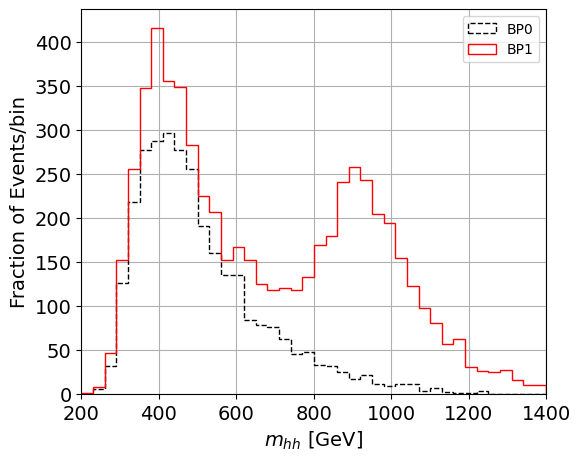

In [79]:
var_name = feats_label.index('m_hh')
range_plot=[200,1400]
bins=40

plt.figure(figsize=(6,5))

# --- Signal  ---
colors_BP = ['black', 'red', 'green', 'orange', 'purple']

plt.hist(X_S0_all[BP_sel0][:,var_name][:3000], bins=bins, lw=5, linestyle='--', range=range_plot, edgecolor=colors_BP[0], histtype='step', label=BP_sel0)
plt.hist(X_S_all[BP_sel1][:,var_name][:6000], bins=bins, lw=3, range=range_plot, edgecolor=colors_BP[1], histtype='step', label=BP_sel1)



plt.grid()
plt.xlabel(r"$m_{hh}$ [GeV]", fontsize=14)
plt.ylabel("Fraction of Events/bin", fontsize=14)
plt.xlim(range_plot)
# plt.yscale('log')
# plt.ylim(1e-7,1e-2)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=10, loc='upper right')
# plt.savefig(mainfolder + "saved-results/MET.pdf", bbox_inches='tight')
plt.show()

# BP0 vs BP1

#### Prepare the data

In [43]:
# FIND THE NUMBER OF EVENTS PER CLASS

class_0_max_evs = len(X_S0_all["BP0"])
class_1_max_evs = len(X_S_all["BP1"])

print(f"class_0_max_evs: {class_0_max_evs}")
print(f"class_1_max_evs: {class_1_max_evs}")

n_to_sample = min(class_0_max_evs, class_1_max_evs)

print(f"\nn_to_sample: {n_to_sample}")

class_0_max_evs: 35675
class_1_max_evs: 153551

n_to_sample: 35675


In [44]:
# PREPARE THE DATA (BP0 vs BP1)

X = np.vstack([
    X_S_all["BP1"][:n_to_sample],
    X_S0_all["BP0"][:n_to_sample]
])

labels_BP = np.concatenate([
    np.full(n_to_sample, "BP1"),
    np.full(n_to_sample, "BP0")
])

y = np.concatenate([
    np.ones(n_to_sample), # Señal = 1
    np.zeros(n_to_sample)  # Fondo (BP0) = 0
])

print(f"Total eventos Señal (Clase 1): {int(np.sum(y))}")
print(f"Total eventos BP0 (Clase 0): {int(len(y) - np.sum(y))}")



# NORMALIZATION

scaler = StandardScaler()
X = scaler.fit_transform(X)



X_trainval, X_test, y_trainval, y_test, BP_trainval, BP_test = train_test_split(
    X, y, labels_BP,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val, BP_train, BP_val = train_test_split(
    X_trainval, y_trainval, BP_trainval,
    test_size=0.25,  # 0.25 * 0.8 = 0.20 total
    stratify=y_trainval,
    random_state=42
)

print()
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Total eventos Señal (Clase 1): 35675
Total eventos BP0 (Clase 0): 35675

Train: (42810, 26)
Val: (14270, 26)
Test: (14270, 26)


[0]	validation_0-logloss:0.68543	validation_0-auc:0.67947	validation_1-logloss:0.68558	validation_1-auc:0.67596
[1]	validation_0-logloss:0.67843	validation_0-auc:0.67980	validation_1-logloss:0.67873	validation_1-auc:0.67639
[2]	validation_0-logloss:0.67210	validation_0-auc:0.67995	validation_1-logloss:0.67256	validation_1-auc:0.67646
[3]	validation_0-logloss:0.66634	validation_0-auc:0.68134	validation_1-logloss:0.66695	validation_1-auc:0.67698
[4]	validation_0-logloss:0.66111	validation_0-auc:0.68132	validation_1-logloss:0.66186	validation_1-auc:0.67695
[5]	validation_0-logloss:0.65634	validation_0-auc:0.68134	validation_1-logloss:0.65724	validation_1-auc:0.67696
[6]	validation_0-logloss:0.65197	validation_0-auc:0.68171	validation_1-logloss:0.65302	validation_1-auc:0.67733
[7]	validation_0-logloss:0.64800	validation_0-auc:0.68172	validation_1-logloss:0.64920	validation_1-auc:0.67731
[8]	validation_0-logloss:0.64435	validation_0-auc:0.68177	validation_1-logloss:0.64567	validation_1-auc:

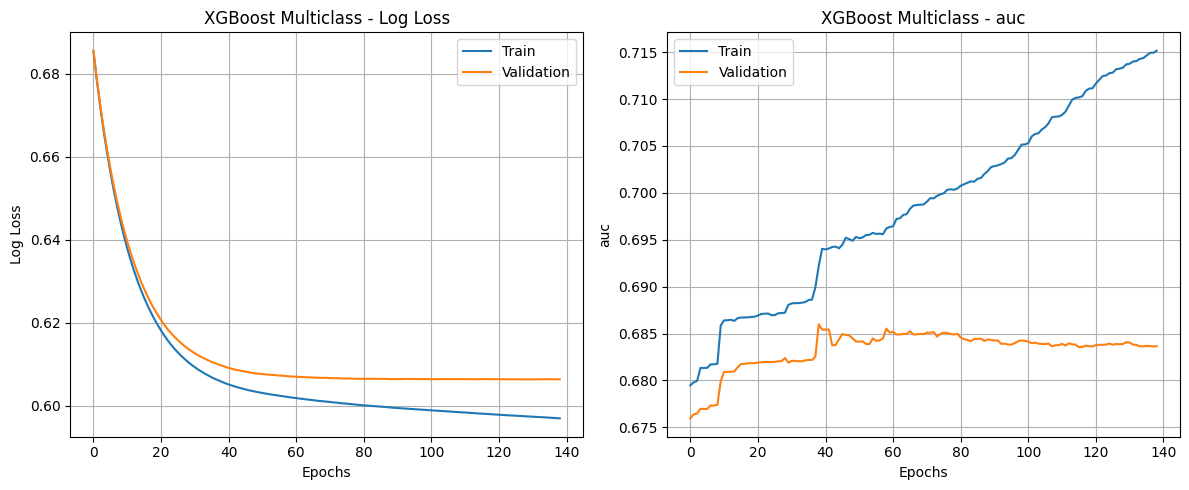

In [45]:
# TRAIN

classifier_bp0 = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=3,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    tree_method='hist',
    random_state=42,
    eval_metric=['logloss', 'auc'],
    early_stopping_rounds=100
)

classifier_bp0.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True
)


results = classifier_bp0.evals_result()

epochs = len(results["validation_0"]["logloss"])
x_axis = range(epochs)

# --- Plot logloss ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x_axis, results["validation_0"]["logloss"], label="Train")
plt.plot(x_axis, results["validation_1"]["logloss"], label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("XGBoost Multiclass - Log Loss")
plt.legend()
plt.grid(True)

# --- Plot auc ---
plt.subplot(1,2,2)
plt.plot(x_axis, results["validation_0"]["auc"], label="Train")
plt.plot(x_axis, results["validation_1"]["auc"], label="Validation")
plt.xlabel("Epochs")
plt.ylabel("auc")
plt.title("XGBoost Multiclass - auc")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# SAVE
classifier_bp0.save_model(mainfolder + "saved-models/classifier_BP0vsBP1_v2PDF.json")

ROC AUC (SM vs LQ): 0.6773


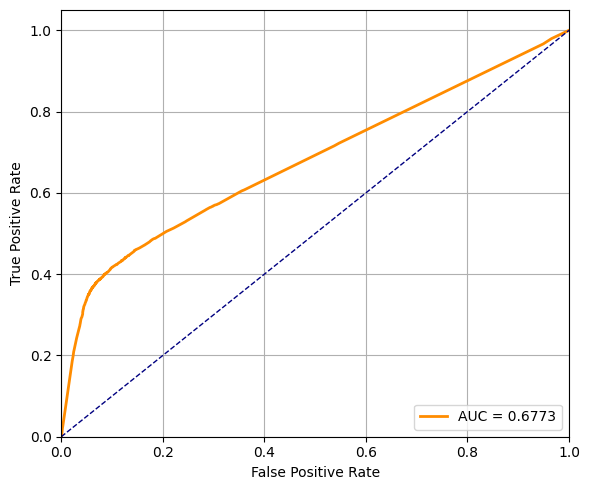

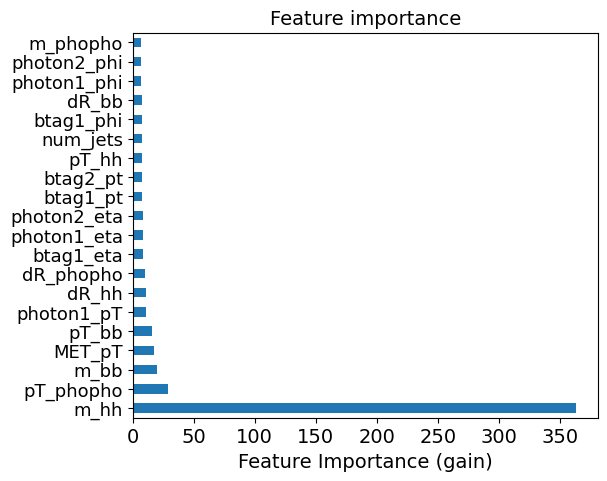

In [46]:
# LOAD
classifier_bp0 = XGBClassifier()
classifier_bp0.load_model(mainfolder + "saved-models/classifier_BP0vsBP1_v2PDF.json")


# ------------------------------------------
# PREDICTION
# ------------------------------------------
y_pred = classifier_bp0.predict_proba(X_test)[:,1]


# Compute ROC curve and AUC
# roc_auc_score(y_test, y_pred, sample_weight=w_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc_hh = auc(fpr, tpr)

print(f"ROC AUC (SM vs LQ): {roc_auc_hh:.4f}")

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_hh:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('ROC Curve:')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
# plt.savefig(mainfolder + 'saved-figures/ROC_1BP.pdf', bbox_inches='tight')
plt.show()





feature_important = classifier_bp0.get_booster().get_score(importance_type='gain')

# convertir f0, f1, f2... a índices
importance_dict = {}

for k, v in feature_important.items():
    idx = int(k[1:])  # quitar la 'f'
    importance_dict[feats_label[idx]] = v

data = (
    pd.DataFrame.from_dict(importance_dict, orient="index", columns=["score"])
    .sort_values(by="score", ascending=False)
)

data.nlargest(20, "score").plot(kind='barh', figsize=(6,5))
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title("Feature importance", fontsize=14)
# plt.savefig(mainfolder + 'saved-figures/feats_1BP.pdf', bbox_inches='tight')
plt.show()

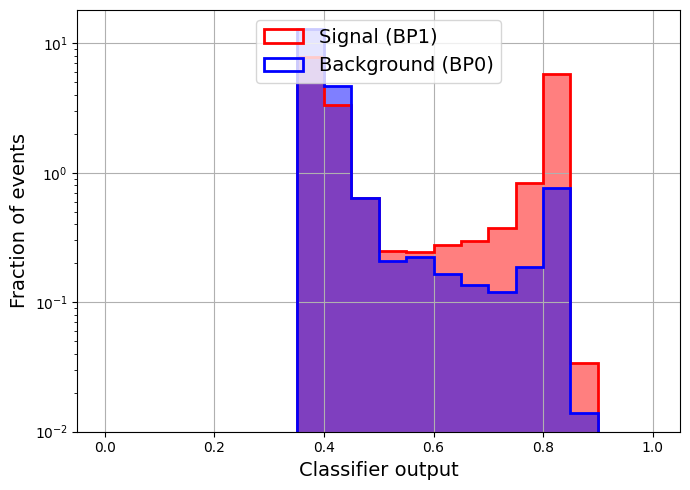

In [47]:
# Scores del clasificador
score_sig = y_pred[y_test == 1]
score_bkg = y_pred[y_test == 0]

bins = np.linspace(0, 1, 21)

plt.figure(figsize=(7,5))

plt.hist(score_sig, bins=bins, density=True, color='red', histtype='step', linewidth=2, label='Signal (BP1)')
plt.hist(score_sig, bins=bins, density=True, color='red',  linewidth=2, alpha=0.5)
plt.hist(score_bkg, bins=bins, density=True, color='blue', histtype='step', linewidth=2, label='Background (BP0)')
plt.hist(score_bkg, bins=bins, density=True, color='blue', linewidth=2, alpha=0.5)

plt.yscale('log')
plt.xlabel("Classifier output",fontsize=14)
plt.ylabel("Fraction of events",fontsize=14)
plt.legend(fontsize=14, loc='upper center')
plt.grid(True)
plt.tight_layout()
plt.show()

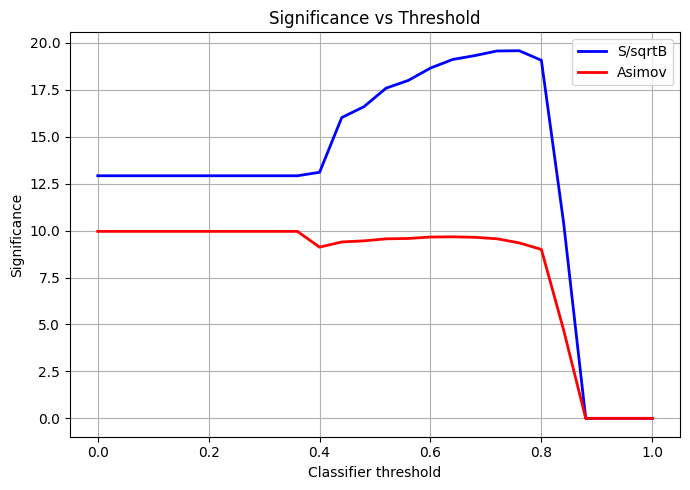

    S/sqrt(B):
Mejor Threshold: 0.760
Máxima Significancia (Asimov): 19.58 sigma
Eventos esperados en punto óptimo: S=20.35, B=1.08

    asimov formula:
Mejor Threshold: 0.000
Máxima Significancia (Asimov): 9.96 sigma
Eventos esperados en punto óptimo: S=63.91, B=24.46


In [48]:

# maximicemos la significancia S/sqrt(B)
# thresholds
thresholds = np.linspace(0, 1, 26)

Z_values = []
Z_values_asimov = []
S_final_yields = []
B_final_yields = []

# Separamos las predicciones por clase
y_pred_S = y_pred[y_test == 1]
y_pred_B = y_pred[y_test == 0]

n_S_test = len(y_pred_S)
n_B_test = len(y_pred_B)

for t in thresholds:
    # 1. Calculamos eficiencias
    eff_S = np.sum(y_pred_S > t) / n_S_test
    eff_B = np.sum(y_pred_B > t) / n_B_test

    # 2. Escalamos segun los eventos esperados
    S = S_expected_all["BP1"] * eff_S
    B = S_expected_BP0 * eff_B

    # 3. Cálculo de significancia
    if B > 1e-6:
        Z = S / np.sqrt(B)
        ratio = S / B
        Z_asimov = np.sqrt(2 * ((S + B) * np.log1p(ratio) - S))
    else:
        Z = 0
        Z_asimov = 0

    Z_values.append(Z)
    Z_values_asimov.append(Z_asimov)
    S_final_yields.append(S)
    B_final_yields.append(B)

Z_values = np.array(Z_values)
Z_values_asimov = np.array(Z_values_asimov)



# plot
plt.figure(figsize=(7,5))

plt.plot(thresholds, Z_values, color='blue', lw=2, label='S/sqrtB')
plt.plot(thresholds, Z_values_asimov, color='red', lw=2, label='Asimov')
plt.xlabel("Classifier threshold")
plt.ylabel("Significance")
plt.title("Significance vs Threshold")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Para encontrar el punto óptimo:
idx_opt_simple = np.argmax(Z_values)
print('    S/sqrt(B):')
print(f"Mejor Threshold: {thresholds[idx_opt_simple]:.3f}")
print(f"Máxima Significancia (Asimov): {Z_values[idx_opt_simple]:.2f} sigma")
print(f"Eventos esperados en punto óptimo: S={S_final_yields[idx_opt_simple]:.2f}, B={B_final_yields[idx_opt_simple]:.2f}")

idx_opt = np.argmax(Z_values_asimov)
print('\n    asimov formula:')
print(f"Mejor Threshold: {thresholds[idx_opt]:.3f}")
print(f"Máxima Significancia (Asimov): {Z_values_asimov[idx_opt]:.2f} sigma")
print(f"Eventos esperados en punto óptimo: S={S_final_yields[idx_opt]:.2f}, B={B_final_yields[idx_opt]:.2f}")

In [49]:
N_bins = 25

y_pred_S = y_pred[y_test == 1]
y_pred_B = y_pred[y_test == 0]

# SM PDF (BP0)
hist_BP0, edges = np.histogram(y_pred_B, bins=N_bins, range=(0,1))
BP0_template = hist_BP0 / (len(y_pred_B) / S_expected_BP0)

# LQ PDF (BP1)
hist_BP1, edges = np.histogram(y_pred_S, bins=N_bins, range=(0,1))
BP1_template = hist_BP1 / (len(y_pred_S) / S_expected_all["BP1"])



print('Significancia Z_asimov binned: ', Z_asimov_exc_nan(BP1_template, BP0_template), 'sigma (exclusion)')
print('Significancia Z_asimov binned: ', Z_asimov_dis_nan(BP1_template, BP0_template), 'sigma (discovery)')
print()

Significancia Z_asimov binned:  8.560471252659127 sigma (exclusion)
Significancia Z_asimov binned:  12.064666564842017 sigma (discovery)



/tmp/ipykernel_4139/3123527265.py:20: RuntimeWarning: invalid value encountered in divide
  return np.sqrt( 2 * np.sum( np.nan_to_num(S - B * np.log(1 + S/B), copy=False, nan=0.0) ) )
/tmp/ipykernel_4139/3123527265.py:16: RuntimeWarning: invalid value encountered in divide
  return np.sqrt( 2 * np.sum( np.nan_to_num((S+B) * np.log(1 + S/B) - S, copy=False, nan=0.0) ) )


# BP0 vs BP with 3<Z<4

#### Prepare the data

In [50]:
# BPs with 3>Z<4

BP_Zmid = [658, 685, 728, 732, 752, 754, 758, 763, 765, 791, 826, 841, 850]

In [51]:
# FIND THE NUMBER OF EVENTS PER CLASS

class_0_max_evs = len(X_S0_all["BP0"])

print(f"class_0_max_evs: {class_0_max_evs}")


# for the signal
num_BP_signal = len(BP_Zmid)

aux = [len(X_S_all["BP"+str(ii)]) for ii in BP_Zmid]
class_1_max_evs = min(aux)


print("num_BP_signal: ", num_BP_signal)
print(f"class_1_max_evs: {class_1_max_evs}")

n_to_sample_class0 = min(class_0_max_evs, class_1_max_evs * num_BP_signal)
n_to_sample_class1 = int(n_to_sample_class0 / num_BP_signal)

print(f"\nn_to_sample (class 0): {n_to_sample_class0}")
print(f"n_to_sample (class 1): {n_to_sample_class1}")

class_0_max_evs: 35675
num_BP_signal:  13
class_1_max_evs: 6704

n_to_sample (class 0): 35675
n_to_sample (class 1): 2744


In [52]:

labels_BP = np.concatenate( [[f'BP{bp_it}'] * n_to_sample_class1 for bp_it in BP_Zmid] +
                            [["BP0"]*n_to_sample_class0] )


X = np.vstack( [X_S_all[f'BP{bp_it}'][:n_to_sample_class1] for bp_it in BP_Zmid] +
               [X_S0_all["BP0"][:n_to_sample_class0]] )


y = np.concatenate([
    np.ones(n_to_sample_class1*len(BP_Zmid)),
    np.zeros(n_to_sample_class0)
])

print(f"Total eventos Señal (Clase 1): {int(np.sum(y))}")
print(f"Total eventos BP0 (Clase 0): {int(len(y) - np.sum(y))}")



# NORMALIZATION

scaler = StandardScaler()
X = scaler.fit_transform(X)



X_trainval, X_test, y_trainval, y_test, BP_trainval, BP_test = train_test_split(
    X, y, labels_BP,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val, BP_train, BP_val = train_test_split(
    X_trainval, y_trainval, BP_trainval,
    test_size=0.25,  # 0.25 * 0.8 = 0.20 total
    stratify=y_trainval,
    random_state=42
)


print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Total eventos Señal (Clase 1): 35672
Total eventos BP0 (Clase 0): 35675
Train: (42807, 26)
Val: (14270, 26)
Test: (14270, 26)


[0]	validation_0-logloss:0.69184	validation_0-auc:0.54837	validation_1-logloss:0.69187	validation_1-auc:0.54738
[1]	validation_0-logloss:0.69066	validation_0-auc:0.54837	validation_1-logloss:0.69071	validation_1-auc:0.54737
[2]	validation_0-logloss:0.68959	validation_0-auc:0.54844	validation_1-logloss:0.68968	validation_1-auc:0.54744
[3]	validation_0-logloss:0.68861	validation_0-auc:0.54850	validation_1-logloss:0.68874	validation_1-auc:0.54743
[4]	validation_0-logloss:0.68773	validation_0-auc:0.54852	validation_1-logloss:0.68788	validation_1-auc:0.54745
[5]	validation_0-logloss:0.68691	validation_0-auc:0.55380	validation_1-logloss:0.68711	validation_1-auc:0.55067
[6]	validation_0-logloss:0.68614	validation_0-auc:0.55566	validation_1-logloss:0.68638	validation_1-auc:0.55267
[7]	validation_0-logloss:0.68546	validation_0-auc:0.55573	validation_1-logloss:0.68569	validation_1-auc:0.55277
[8]	validation_0-logloss:0.68480	validation_0-auc:0.55588	validation_1-logloss:0.68507	validation_1-auc:

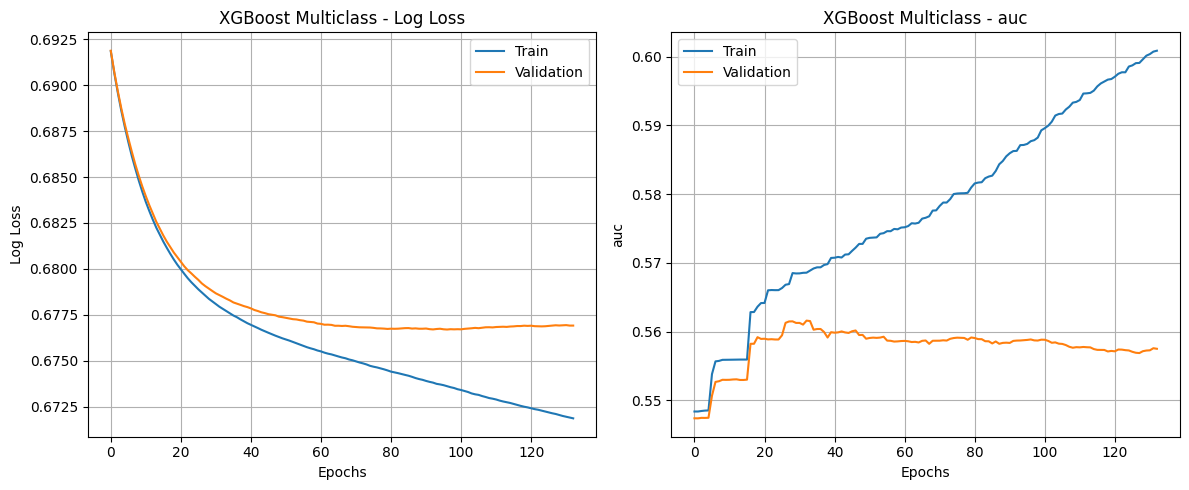

In [53]:
# TRAIN

classifier_bp0 = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=3,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    tree_method='hist',
    random_state=42,
    eval_metric=['logloss', 'auc'],
    early_stopping_rounds=100
)

classifier_bp0.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True
)


results = classifier_bp0.evals_result()

epochs = len(results["validation_0"]["logloss"])
x_axis = range(epochs)

# --- Plot logloss ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x_axis, results["validation_0"]["logloss"], label="Train")
plt.plot(x_axis, results["validation_1"]["logloss"], label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("XGBoost Multiclass - Log Loss")
plt.legend()
plt.grid(True)

# --- Plot auc ---
plt.subplot(1,2,2)
plt.plot(x_axis, results["validation_0"]["auc"], label="Train")
plt.plot(x_axis, results["validation_1"]["auc"], label="Validation")
plt.xlabel("Epochs")
plt.ylabel("auc")
plt.title("XGBoost Multiclass - auc")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# SAVE
classifier_bp0.save_model(mainfolder + "saved-models/classifier_BP0vsBPs3Z4_v2PDF.json")

ROC AUC (SM vs LQ): 0.5526


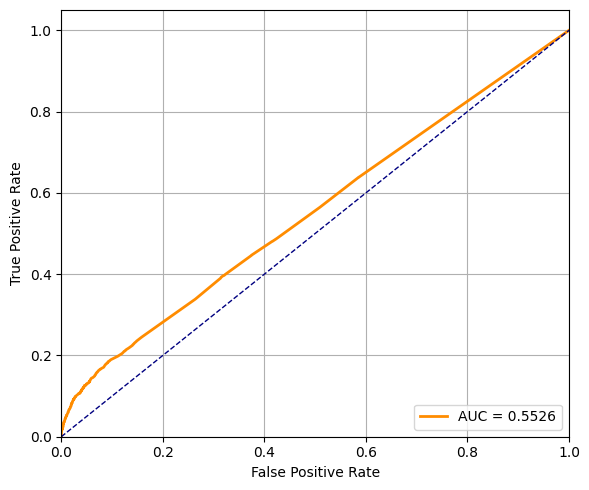

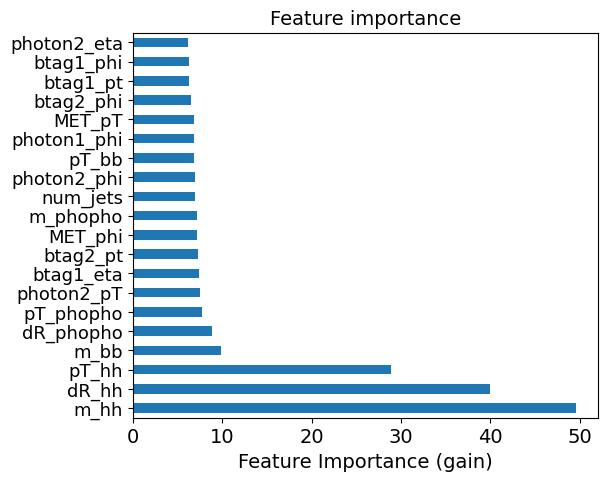

In [54]:
# LOAD
classifier_bp0 = XGBClassifier()
classifier_bp0.load_model(mainfolder + "saved-models/classifier_BP0vsBPs3Z4_v2PDF.json")


# ------------------------------------------
# PREDICTION
# ------------------------------------------
y_pred = classifier_bp0.predict_proba(X_test)[:,1]


# Compute ROC curve and AUC
# roc_auc_score(y_test, y_pred, sample_weight=w_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc_hh = auc(fpr, tpr)

print(f"ROC AUC (SM vs LQ): {roc_auc_hh:.4f}")

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_hh:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('ROC Curve:')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
# plt.savefig(mainfolder + 'saved-figures/ROC_1BP.pdf', bbox_inches='tight')
plt.show()





feature_important = classifier_bp0.get_booster().get_score(importance_type='gain')

# convertir f0, f1, f2... a índices
importance_dict = {}

for k, v in feature_important.items():
    idx = int(k[1:])  # quitar la 'f'
    importance_dict[feats_label[idx]] = v

data = (
    pd.DataFrame.from_dict(importance_dict, orient="index", columns=["score"])
    .sort_values(by="score", ascending=False)
)

data.nlargest(20, "score").plot(kind='barh', figsize=(6,5))
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title("Feature importance", fontsize=14)
# plt.savefig(mainfolder + 'saved-figures/feats_1BP.pdf', bbox_inches='tight')
plt.show()

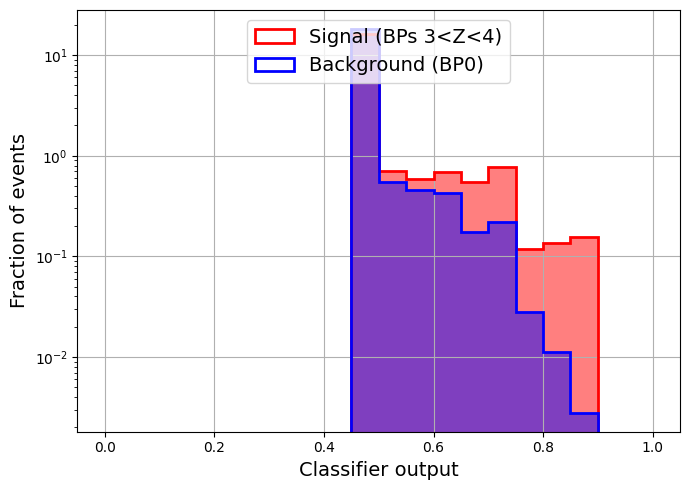

In [55]:
# Scores del clasificador
score_sig = y_pred[y_test == 1]
score_bkg = y_pred[y_test == 0]

bins = np.linspace(0, 1, 21)

plt.figure(figsize=(7,5))

plt.hist(score_sig, bins=bins, density=True, color='red', histtype='step', linewidth=2, label='Signal (BPs 3<Z<4)')
plt.hist(score_sig, bins=bins, density=True, color='red',  linewidth=2, alpha=0.5)
plt.hist(score_bkg, bins=bins, density=True, color='blue', histtype='step', linewidth=2, label='Background (BP0)')
plt.hist(score_bkg, bins=bins, density=True, color='blue', linewidth=2, alpha=0.5)

plt.yscale('log')
plt.xlabel("Classifier output",fontsize=14)
plt.ylabel("Fraction of events",fontsize=14)
plt.legend(fontsize=14, loc='upper center')
plt.grid(True)
plt.tight_layout()
plt.show()

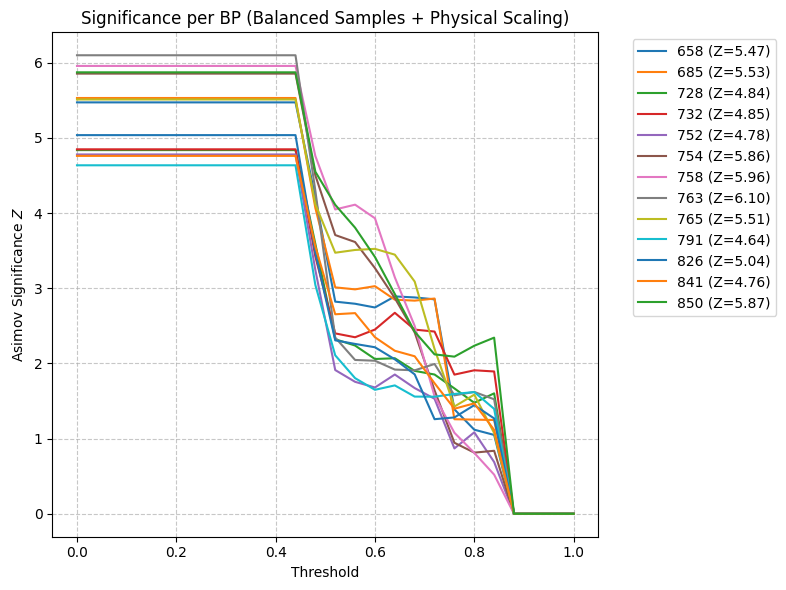

------------------------------
       658 | Zmax = 5.473 | at t = 0.000 |      S(o(x)>t) = 31.698
       685 | Zmax = 5.531 | at t = 0.000 |      S(o(x)>t) = 32.082
       728 | Zmax = 4.838 | at t = 0.000 |      S(o(x)>t) = 27.573
       732 | Zmax = 4.849 | at t = 0.000 |      S(o(x)>t) = 27.641
       752 | Zmax = 4.780 | at t = 0.000 |      S(o(x)>t) = 27.202
       754 | Zmax = 5.856 | at t = 0.000 |      S(o(x)>t) = 34.238
       758 | Zmax = 5.958 | at t = 0.000 |      S(o(x)>t) = 34.922
       763 | Zmax = 6.100 | at t = 0.000 |      S(o(x)>t) = 35.879
       765 | Zmax = 5.512 | at t = 0.000 |      S(o(x)>t) = 31.953
       791 | Zmax = 4.636 | at t = 0.000 |      S(o(x)>t) = 26.284
       826 | Zmax = 5.037 | at t = 0.000 |      S(o(x)>t) = 28.856
       841 | Zmax = 4.761 | at t = 0.000 |      S(o(x)>t) = 27.081
       850 | Zmax = 5.873 | at t = 0.000 |      S(o(x)>t) = 34.353


In [56]:
###################
#   for each BP   #
###################

thresholds = np.linspace(0, 1, 26)
results_Zmid = {}

# Pre-calculamos la predicción del background para no repetir el filtro en cada loop
y_pred_B = y_pred[y_test == 0]
n_B_test = len(y_pred_B)


plt.figure(figsize=(8, 6))

for bp_it in BP_Zmid:
    # Filtramos las predicciones solo de este BP
    y_pred_S_bp = y_pred[BP_test == f'BP{bp_it}']
    n_S_test_bp = len(y_pred_S_bp)

    # Obtenemos su S_expected
    S_bp = S_expected_all[f'BP{bp_it}']

    Z_values_bp = []

    for t in thresholds:
        # Eficiencias para este threshold
        eff_S = np.sum(y_pred_S_bp > t) / n_S_test_bp
        eff_B = np.sum(y_pred_B > t) / n_B_test

        # Escalado físico
        S = S_bp * eff_S
        B = S_expected_BP0 * eff_B

        if B > 1e-6:
            Z = np.sqrt(2 * ((S + B) * np.log1p(S / B) - S))
        else:
            Z = 0
        Z_values_bp.append(Z)

    Z_values_bp = np.array(Z_values_bp)
    best_idx = np.argmax(Z_values_bp)

    eff_bp = np.mean(y_pred[BP_test == f'BP{bp_it}'] > thresholds[best_idx])
    yield_bp  = S_bp * eff_bp

    # Guardar resultados
    results_Zmid[bp_it] = {
        "Zmax": Z_values_bp[best_idx],
        "threshold": thresholds[best_idx],
        "eff": eff_bp,
        "yield": yield_bp
    }

    # Plotear directamente en el mismo loop
    plt.plot(thresholds, Z_values_bp, label=f"{bp_it} (Z={Z_values_bp[best_idx]:.2f})")

# Finalizar el plot
plt.xlabel("Threshold")
plt.ylabel("Asimov Significance $Z$")
plt.title("Significance per BP (Balanced Samples + Physical Scaling)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Imprimir resumen
ZZ = []
print("-" * 30)
for bp_it, res in results_Zmid.items():
    print(f"{bp_it:10} | Zmax = {res['Zmax']:.3f} | at t = {res['threshold']:.3f} |      S(o(x)>t) = {res['yield']:.3f}")
    ZZ.append(res['Zmax'])

In [57]:
N_bins = 25

y_pred_S = y_pred[y_test == 1]
y_pred_B = y_pred[y_test == 0]

# SM PDF (BP0)
hist_BP0, edges = np.histogram(y_pred_B, bins=N_bins, range=(0,1))
BP0_template = hist_BP0 / (len(y_pred_B) / S_expected_BP0)

# LQ PDF
Z_values_exc = {}
Z_values_dis = {}

for bp_it in BP_Zmid:
    # Filtramos las predicciones solo de este BP
    y_pred_S_bp = y_pred[BP_test == f'BP{bp_it}']
    n_S_test_bp = len(y_pred_S_bp)

    # Obtenemos su S_expected
    S_bp = S_expected_all[f'BP{bp_it}']


    hist_BP, edges = np.histogram(y_pred_S_bp, bins=N_bins, range=(0,1))
    BP_template = hist_BP / (len(y_pred_S_bp) / S_bp)

    z_exc_aux = Z_asimov_exc_nan(BP_template, BP0_template)
    z_dis_aux = Z_asimov_dis_nan(BP_template, BP0_template)

    Z_values_exc[f'BP{bp_it}'] = z_exc_aux
    Z_values_dis[f'BP{bp_it}'] = z_dis_aux

    print('BP: ', bp_it, '    Z binned: ', z_dis_aux)
    # print('Z_asimov_exc binned: ', z_exc_aux)


BP:  658     Z binned:  5.928979487734964
BP:  685     Z binned:  6.008594793265166
BP:  728     Z binned:  5.182721304171316
BP:  732     Z binned:  5.398628275368322
BP:  752     Z binned:  4.961968559408316
BP:  754     Z binned:  6.254167307332547
BP:  758     Z binned:  6.514790535745794
BP:  763     Z binned:  6.335892485115271
BP:  765     Z binned:  6.088702933519768
BP:  791     Z binned:  4.928558474629665
BP:  826     Z binned:  5.29676179168843
BP:  841     Z binned:  5.100136210500537
BP:  850     Z binned:  6.606706983990903


/tmp/ipykernel_4139/3123527265.py:20: RuntimeWarning: invalid value encountered in divide
  return np.sqrt( 2 * np.sum( np.nan_to_num(S - B * np.log(1 + S/B), copy=False, nan=0.0) ) )
/tmp/ipykernel_4139/3123527265.py:16: RuntimeWarning: invalid value encountered in divide
  return np.sqrt( 2 * np.sum( np.nan_to_num((S+B) * np.log(1 + S/B) - S, copy=False, nan=0.0) ) )


# BP0 vs BP that overlap considering S_predicted

#### Prepare the data

In [58]:
BP_overlap

[586,
 635,
 658,
 673,
 678,
 684,
 685,
 728,
 732,
 752,
 754,
 758,
 763,
 765,
 787,
 791,
 826,
 841,
 850,
 855,
 872,
 875,
 881,
 1017,
 1035,
 1036,
 1087,
 1103,
 1104]

In [59]:
# FIND THE NUMBER OF EVENTS PER CLASS

class_0_max_evs = len(X_S0_all["BP0"])

print(f"class_0_max_evs: {class_0_max_evs}")


# for the signal
num_BP_signal = len(BP_overlap)

aux = [len(X_S_all["BP"+str(ii)]) for ii in BP_overlap]
class_1_max_evs = min(aux)


print("num_BP_signal: ", num_BP_signal)
print(f"class_1_max_evs: {class_1_max_evs}")

n_to_sample_class0 = min(class_0_max_evs, class_1_max_evs * num_BP_signal)
n_to_sample_class1 = int(n_to_sample_class0 / num_BP_signal)

print(f"\nn_to_sample (class 0): {n_to_sample_class0}")
print(f"n_to_sample (class 1): {n_to_sample_class1}")

class_0_max_evs: 35675
num_BP_signal:  29
class_1_max_evs: 3708

n_to_sample (class 0): 35675
n_to_sample (class 1): 1230


In [60]:

labels_BP = np.concatenate( [[f'BP{bp_it}'] * n_to_sample_class1 for bp_it in BP_overlap] +
                            [["BP0"]*n_to_sample_class0] )


X = np.vstack( [X_S_all[f'BP{bp_it}'][:n_to_sample_class1] for bp_it in BP_overlap] +
               [X_S0_all["BP0"][:n_to_sample_class0]] )


y = np.concatenate([
    np.ones(n_to_sample_class1*len(BP_overlap)),
    np.zeros(n_to_sample_class0)
])

print(f"Total eventos Señal (Clase 1): {int(np.sum(y))}")
print(f"Total eventos BP0 (Clase 0): {int(len(y) - np.sum(y))}")



# NORMALIZATION

scaler_modelB = StandardScaler()
X = scaler_modelB.fit_transform(X)



X_trainval, X_test, y_trainval, y_test, BP_trainval, BP_test = train_test_split(
    X, y, labels_BP,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val, BP_train, BP_val = train_test_split(
    X_trainval, y_trainval, BP_trainval,
    test_size=0.25,  # 0.25 * 0.8 = 0.20 total
    stratify=y_trainval,
    random_state=42
)


print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Total eventos Señal (Clase 1): 35670
Total eventos BP0 (Clase 0): 35675
Train: (42807, 26)
Val: (14269, 26)
Test: (14269, 26)


[0]	validation_0-logloss:0.69168	validation_0-auc:0.55544	validation_1-logloss:0.69177	validation_1-auc:0.55309
[1]	validation_0-logloss:0.69034	validation_0-auc:0.55570	validation_1-logloss:0.69051	validation_1-auc:0.55332
[2]	validation_0-logloss:0.68912	validation_0-auc:0.55740	validation_1-logloss:0.68934	validation_1-auc:0.55574
[3]	validation_0-logloss:0.68801	validation_0-auc:0.55728	validation_1-logloss:0.68835	validation_1-auc:0.55576
[4]	validation_0-logloss:0.68698	validation_0-auc:0.56240	validation_1-logloss:0.68740	validation_1-auc:0.56104
[5]	validation_0-logloss:0.68605	validation_0-auc:0.56245	validation_1-logloss:0.68652	validation_1-auc:0.56148
[6]	validation_0-logloss:0.68516	validation_0-auc:0.56301	validation_1-logloss:0.68570	validation_1-auc:0.56256
[7]	validation_0-logloss:0.68431	validation_0-auc:0.56326	validation_1-logloss:0.68502	validation_1-auc:0.56270
[8]	validation_0-logloss:0.68356	validation_0-auc:0.56326	validation_1-logloss:0.68438	validation_1-auc:

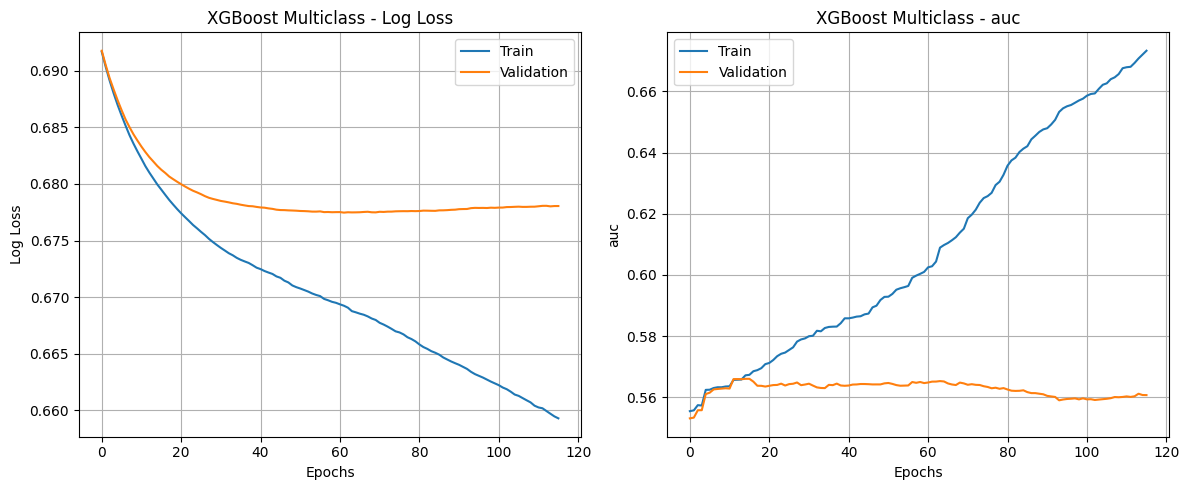

In [61]:
# TRAIN

classifier_bp0 = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.05,
    max_depth=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    tree_method='hist',
    random_state=42,
    eval_metric=['logloss', 'auc'],
    early_stopping_rounds=100
)

classifier_bp0.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True
)


results = classifier_bp0.evals_result()

epochs = len(results["validation_0"]["logloss"])
x_axis = range(epochs)

# --- Plot logloss ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x_axis, results["validation_0"]["logloss"], label="Train")
plt.plot(x_axis, results["validation_1"]["logloss"], label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("XGBoost Multiclass - Log Loss")
plt.legend()
plt.grid(True)

# --- Plot auc ---
plt.subplot(1,2,2)
plt.plot(x_axis, results["validation_0"]["auc"], label="Train")
plt.plot(x_axis, results["validation_1"]["auc"], label="Validation")
plt.xlabel("Epochs")
plt.ylabel("auc")
plt.title("XGBoost Multiclass - auc")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# SAVE
classifier_bp0.save_model(mainfolder + "saved-models/classifier_BP0vsBPoverlap_v2PDF.json")

ROC AUC (SM vs LQ): 0.5485


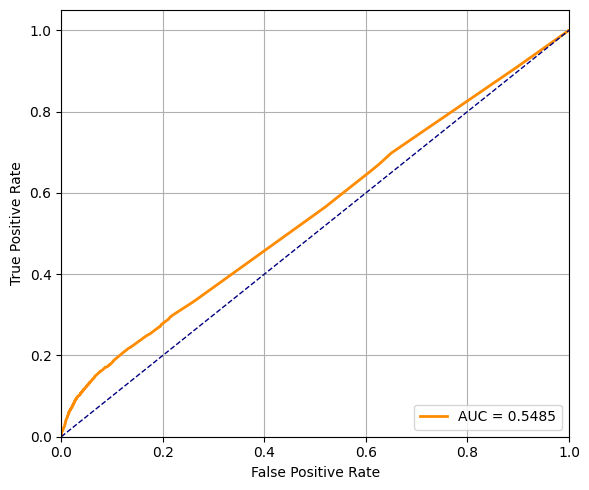

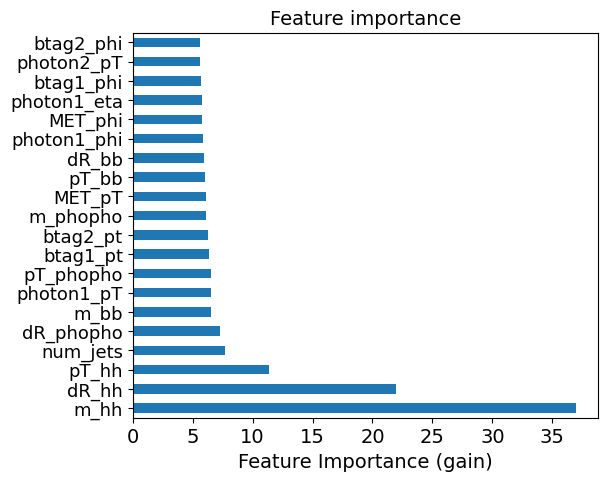

In [62]:
# LOAD
classifier_bp0 = XGBClassifier()
classifier_bp0.load_model(mainfolder + "saved-models/classifier_BP0vsBPoverlap_v2PDF.json")


# ------------------------------------------
# PREDICTION
# ------------------------------------------
y_pred = classifier_bp0.predict_proba(X_test)[:,1]


# Compute ROC curve and AUC
# roc_auc_score(y_test, y_pred, sample_weight=w_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc_hh = auc(fpr, tpr)

print(f"ROC AUC (SM vs LQ): {roc_auc_hh:.4f}")

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_hh:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('ROC Curve:')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
# plt.savefig(mainfolder + 'saved-figures/ROC_1BP.pdf', bbox_inches='tight')
plt.show()





feature_important = classifier_bp0.get_booster().get_score(importance_type='gain')

# convertir f0, f1, f2... a índices
importance_dict = {}

for k, v in feature_important.items():
    idx = int(k[1:])  # quitar la 'f'
    importance_dict[feats_label[idx]] = v

data = (
    pd.DataFrame.from_dict(importance_dict, orient="index", columns=["score"])
    .sort_values(by="score", ascending=False)
)

data.nlargest(20, "score").plot(kind='barh', figsize=(6,5))
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.xlabel("Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title("Feature importance", fontsize=14)
# plt.savefig(mainfolder + 'saved-figures/feats_1BP.pdf', bbox_inches='tight')
plt.show()

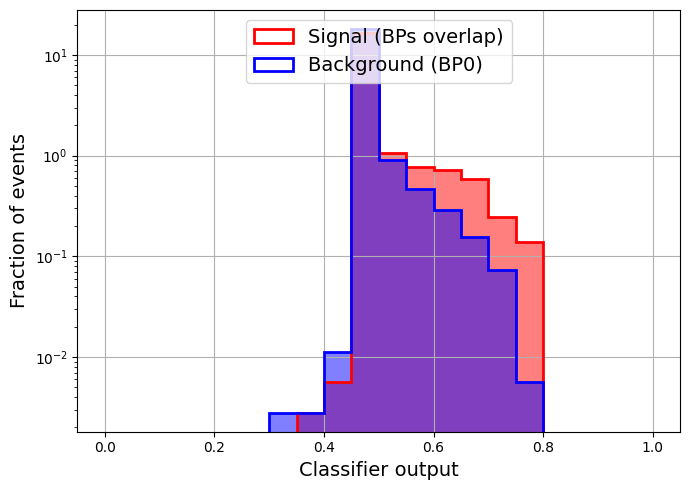

In [63]:
# Scores del clasificador
score_sig = y_pred[y_test == 1]
score_bkg = y_pred[y_test == 0]

bins = np.linspace(0, 1, 21)

plt.figure(figsize=(7,5))

plt.hist(score_sig, bins=bins, density=True, color='red', histtype='step', linewidth=2, label='Signal (BPs overlap)')
plt.hist(score_sig, bins=bins, density=True, color='red',  linewidth=2, alpha=0.5)
plt.hist(score_bkg, bins=bins, density=True, color='blue', histtype='step', linewidth=2, label='Background (BP0)')
plt.hist(score_bkg, bins=bins, density=True, color='blue', linewidth=2, alpha=0.5)

plt.yscale('log')
plt.xlabel("Classifier output",fontsize=14)
plt.ylabel("Fraction of events",fontsize=14)
plt.legend(fontsize=14, loc='upper center')
plt.grid(True)
plt.tight_layout()
plt.show()

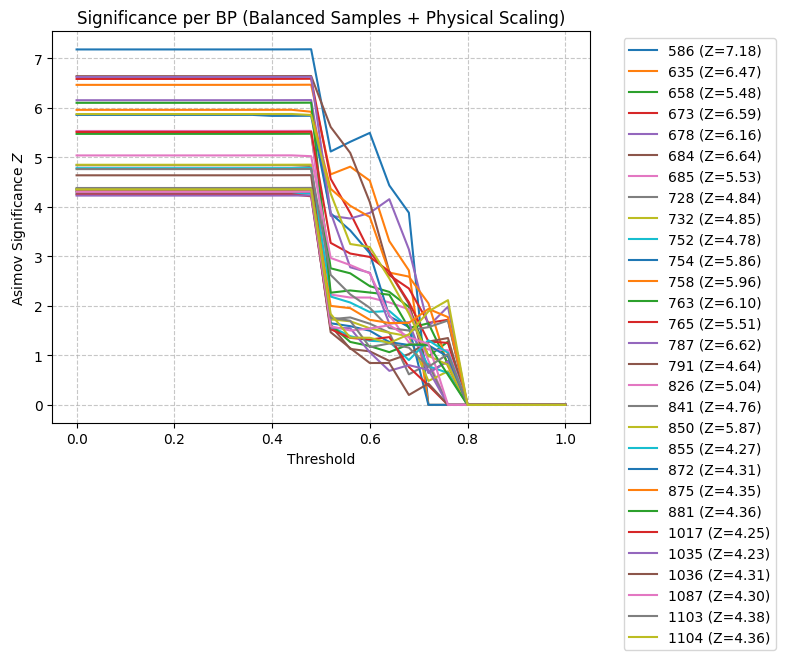

------------------------------
       586 | Zmax = 7.181 | at t = 0.480 |      S(o(x)>t) = 43.317
       635 | Zmax = 6.465 | at t = 0.480 |      S(o(x)>t) = 38.346
       658 | Zmax = 5.476 | at t = 0.480 |      S(o(x)>t) = 31.698
       673 | Zmax = 6.585 | at t = 0.480 |      S(o(x)>t) = 39.170
       678 | Zmax = 6.155 | at t = 0.480 |      S(o(x)>t) = 36.234
       684 | Zmax = 6.641 | at t = 0.480 |      S(o(x)>t) = 39.554
       685 | Zmax = 5.534 | at t = 0.480 |      S(o(x)>t) = 32.082
       728 | Zmax = 4.839 | at t = 0.440 |      S(o(x)>t) = 27.573
       732 | Zmax = 4.851 | at t = 0.480 |      S(o(x)>t) = 27.641
       752 | Zmax = 4.782 | at t = 0.480 |      S(o(x)>t) = 27.202
       754 | Zmax = 5.856 | at t = 0.360 |      S(o(x)>t) = 34.238
       758 | Zmax = 5.959 | at t = 0.440 |      S(o(x)>t) = 34.922
       763 | Zmax = 6.103 | at t = 0.480 |      S(o(x)>t) = 35.879
       765 | Zmax = 5.514 | at t = 0.480 |      S(o(x)>t) = 31.953
       787 | Zmax = 6.624 | at 

In [64]:
###################
#   for each BP   #
###################

thresholds = np.linspace(0, 1, 26)
results_Zmid = {}

# Pre-calculamos la predicción del background para no repetir el filtro en cada loop
y_pred_B = y_pred[y_test == 0]
n_B_test = len(y_pred_B)


plt.figure(figsize=(8, 6))

for bp_it in BP_overlap:
    # Filtramos las predicciones solo de este BP
    y_pred_S_bp = y_pred[BP_test == f'BP{bp_it}']
    n_S_test_bp = len(y_pred_S_bp)

    # Obtenemos su S_expected
    S_bp = S_expected_all[f'BP{bp_it}']

    Z_values_bp = []

    for t in thresholds:
        # Eficiencias para este threshold
        eff_S = np.sum(y_pred_S_bp > t) / n_S_test_bp
        eff_B = np.sum(y_pred_B > t) / n_B_test

        # Escalado físico
        S = S_bp * eff_S
        B = S_expected_BP0 * eff_B

        if B > 1e-6:
            Z = np.sqrt(2 * ((S + B) * np.log1p(S / B) - S))
        else:
            Z = 0
        Z_values_bp.append(Z)

    Z_values_bp = np.array(Z_values_bp)
    best_idx = np.argmax(Z_values_bp)

    eff_bp = np.mean(y_pred[BP_test == f'BP{bp_it}'] > thresholds[best_idx])
    yield_bp  = S_bp * eff_bp

    # Guardar resultados
    results_Zmid[bp_it] = {
        "Zmax": Z_values_bp[best_idx],
        "threshold": thresholds[best_idx],
        "eff": eff_bp,
        "yield": yield_bp
    }

    # Plotear directamente en el mismo loop
    plt.plot(thresholds, Z_values_bp, label=f"{bp_it} (Z={Z_values_bp[best_idx]:.2f})")

# Finalizar el plot
plt.xlabel("Threshold")
plt.ylabel("Asimov Significance $Z$")
plt.title("Significance per BP (Balanced Samples + Physical Scaling)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Imprimir resumen
ZZ = []
print("-" * 30)
for bp_it, res in results_Zmid.items():
    print(f"{bp_it:10} | Zmax = {res['Zmax']:.3f} | at t = {res['threshold']:.3f} |      S(o(x)>t) = {res['yield']:.3f}")
    ZZ.append(res['Zmax'])

In [65]:
N_bins = 25

y_pred_S = y_pred[y_test == 1]
y_pred_B = y_pred[y_test == 0]

# SM PDF (BP0)
hist_BP0, edges = np.histogram(y_pred_B, bins=N_bins, range=(0,1))
BP0_template = hist_BP0 / (len(y_pred_B) / S_expected_BP0)

# LQ PDF
Z_values_exc = {}
Z_values_dis = {}

for bp_it in BP_overlap:
    # Filtramos las predicciones solo de este BP
    y_pred_S_bp = y_pred[BP_test == f'BP{bp_it}']
    n_S_test_bp = len(y_pred_S_bp)

    # Obtenemos su S_expected
    S_bp = S_expected_all[f'BP{bp_it}']


    hist_BP, edges = np.histogram(y_pred_S_bp, bins=N_bins, range=(0,1))
    BP_template = hist_BP / (len(y_pred_S_bp) / S_bp)

    z_exc_aux = Z_asimov_exc_nan(BP_template, BP0_template)
    z_dis_aux = Z_asimov_dis_nan(BP_template, BP0_template)

    Z_values_exc[f'BP{bp_it}'] = z_exc_aux
    Z_values_dis[f'BP{bp_it}'] = z_dis_aux

    print('BP: ', bp_it, '    Z binned: ', z_dis_aux)
    # print('Z_asimov_exc binned: ', z_exc_aux)


BP:  586     Z binned:  8.255386632439805
BP:  635     Z binned:  7.302534282683083
BP:  658     Z binned:  5.775767603646164
BP:  673     Z binned:  7.186874987655654
BP:  678     Z binned:  7.021892079159073
BP:  684     Z binned:  7.624112110225627
BP:  685     Z binned:  5.7118276206428025
BP:  728     Z binned:  5.027904801337742
BP:  732     Z binned:  4.956928335182004
BP:  752     Z binned:  4.9585125852809755
BP:  754     Z binned:  6.36084692553164
BP:  758     Z binned:  6.747997774105022
BP:  763     Z binned:  6.345138899263754
BP:  765     Z binned:  5.94202727022126
BP:  787     Z binned:  6.993714211785178
BP:  791     Z binned:  4.818577899491765
BP:  826     Z binned:  5.423559910140358
BP:  841     Z binned:  5.119445326191855
BP:  850     Z binned:  6.494892742752115
BP:  855     Z binned:  4.450066612918105
BP:  872     Z binned:  4.472689412357677
BP:  875     Z binned:  4.73679928747748
BP:  881     Z binned:  4.497156520026967
BP:  1017     Z binned:  4.43368211

/tmp/ipykernel_4139/3123527265.py:20: RuntimeWarning: invalid value encountered in divide
  return np.sqrt( 2 * np.sum( np.nan_to_num(S - B * np.log(1 + S/B), copy=False, nan=0.0) ) )
/tmp/ipykernel_4139/3123527265.py:16: RuntimeWarning: invalid value encountered in divide
  return np.sqrt( 2 * np.sum( np.nan_to_num((S+B) * np.log(1 + S/B) - S, copy=False, nan=0.0) ) )


# BP0 vs BP (including QCD and single Higgs background)

In [66]:
# Prediction classifier A
X0 = X_S0_all["BP0"]
X0_scaled = scaler.transform(X0)

y_pred_BP0_MA = classifier_hh.predict_proba(X0_scaled)[:, 1]


y_pred_BP_MA = {}
for bp_it in BP_overlap:
    XBP = X_S_all[f"BP{bp_it}"]
    XBP_scaled = scaler.transform(XBP)

    y_pred_BP_MA[f"BP{bp_it}"] = classifier_hh.predict_proba(XBP_scaled)[:, 1]


XSM = np.vstack( [X_B_all["bbaa"][:n_to_sample_B_all["bbaa"]]] +
                 [X_B_all["tth"][:n_to_sample_B_all["tth"]]] +
                 [X_B_all["zh"][:n_to_sample_B_all["zh"]]] )

XSM_scaled = scaler.transform(XSM)

y_pred_SM_MA = classifier_hh.predict_proba(XSM_scaled)[:, 1]

In [67]:
# Prediction classifier B
X0 = X_S0_all["BP0"]
X0_scaled = scaler_modelB.transform(X0)

y_pred_BP0_MB = classifier_bp0.predict_proba(X0_scaled)[:, 1]
n_BP0_bi = len(y_pred_BP0_MB)


y_pred_BP_MB = {}
n_BP_bi = {}
for bp_it in BP_overlap:
    XBP = X_S_all[f"BP{bp_it}"]
    XBP_scaled = scaler_modelB.transform(XBP)

    y_pred_BP_MB[f"BP{bp_it}"] = classifier_bp0.predict_proba(XBP_scaled)[:, 1]
    n_BP_bi[f"BP{bp_it}"] = len(y_pred_BP_MB[f"BP{bp_it}"])


XSM = np.vstack( [X_B_all["bbaa"][:n_to_sample_B_all["bbaa"]]] +
                 [X_B_all["tth"][:n_to_sample_B_all["tth"]]] +
                 [X_B_all["zh"][:n_to_sample_B_all["zh"]]] )

XSM_scaled = scaler_modelB.transform(XSM)

y_pred_SM_MB = classifier_bp0.predict_proba(XSM_scaled)[:, 1]
n_SM_bi = len(y_pred_SM_MB)

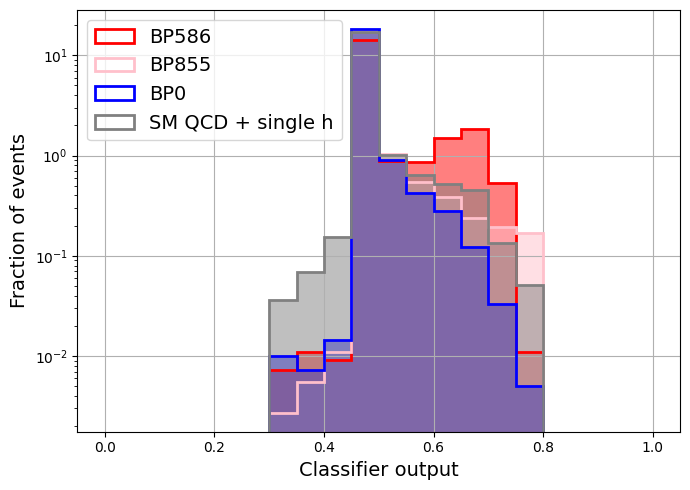

In [74]:
# Scores del clasificador
bins = np.linspace(0, 1, 21)

plt.figure(figsize=(7,5))

plt.hist(y_pred_BP_MB["BP586"], bins=bins, density=True, color='red', histtype='step', linewidth=2, label='BP586')
plt.hist(y_pred_BP_MB["BP586"], bins=bins, density=True, color='red',  linewidth=2, alpha=0.5)
plt.hist(y_pred_BP_MB["BP855"], bins=bins, density=True, color='pink', histtype='step', linewidth=2, label='BP855')
plt.hist(y_pred_BP_MB["BP855"], bins=bins, density=True, color='pink',  linewidth=2, alpha=0.5)
plt.hist(y_pred_BP0_MB, bins=bins, density=True, color='blue', histtype='step', linewidth=2, label='BP0')
plt.hist(y_pred_BP0_MB, bins=bins, density=True, color='blue', linewidth=2, alpha=0.5)
plt.hist(y_pred_SM_MB, bins=bins, density=True, color='gray', histtype='step', linewidth=2, label='SM QCD + single h')
plt.hist(y_pred_SM_MB, bins=bins, density=True, color='gray', linewidth=2, alpha=0.5)

plt.yscale('log')
plt.xlabel("Classifier output",fontsize=14)
plt.ylabel("Fraction of events",fontsize=14)
plt.legend(fontsize=14, loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [70]:
# THIS ONE DOES NOT HAVE A THRESHOLD FOR THE SECOND CLASSIFIER

###################
#   for each BP   #
###################

threshold_A = 0.96

# SM (QCD + single higgs) que contamina ya que pasa el threshold del clasificador A
y_pred_SM_MB_filtered = y_pred_SM_MB[y_pred_SM_MA > threshold_A]

eff_SM = np.sum(y_pred_SM_MB_filtered) / n_SM_bi

SM_evs = B_expected * eff_SM



# el BP0 que pasa el threshold del clasificador A
y_pred_BP0_MB_filtered = y_pred_BP0_MB[y_pred_BP0_MA > threshold_A]

eff_BP0 = np.sum(y_pred_BP0_MB_filtered) / n_BP0_bi

BP0_evs = S_expected_BP0 * eff_BP0




Z_BP0_vs_BP_wSM = {}

for bp_it in BP_overlap:
    # Filtramos las predicciones solo de este BP y ademas pedimos que pasen el threshold del clasificador A
    y_pred_BP_MB_filtered = y_pred_BP_MB[f'BP{bp_it}'][y_pred_BP_MA[f'BP{bp_it}'] > threshold_A]

    eff_BP = np.sum(y_pred_BP_MB_filtered) / n_BP_bi[f'BP{bp_it}']

    BP_evs = S_expected_all[f'BP{bp_it}'] * eff_BP



    S = BP_evs - BP0_evs
    B = BP0_evs + SM_evs

    if B > 1e-6:
        Z = np.sqrt(2 * ((S + B) * np.log1p(S / B) - S))
    else:
        Z = 0

    Z_BP0_vs_BP_wSM[f'BP{bp_it}'] = Z


# print
for bp_it, res in Z_BP0_vs_BP_wSM.items():
    print(f"{bp_it:10} | Z = {res:.3f} ")

BP586      | Z = 1.023 
BP635      | Z = 0.762 
BP658      | Z = 0.324 
BP673      | Z = 0.781 
BP678      | Z = 0.634 
BP684      | Z = 0.816 
BP685      | Z = 0.368 
BP728      | Z = 0.133 
BP732      | Z = 0.115 
BP752      | Z = 0.146 
BP754      | Z = 0.551 
BP758      | Z = 0.626 
BP763      | Z = 0.355 
BP765      | Z = 0.382 
BP787      | Z = 0.668 
BP791      | Z = 0.109 
BP826      | Z = 0.305 
BP841      | Z = 0.184 
BP850      | Z = 0.507 
BP855      | Z = 0.005 
BP872      | Z = 0.045 
BP875      | Z = 0.053 
BP881      | Z = 0.001 
BP1017     | Z = 0.010 
BP1035     | Z = 0.018 
BP1036     | Z = 0.071 
BP1087     | Z = 0.036 
BP1103     | Z = 0.056 
BP1104     | Z = 0.010 


In [71]:
###################
#   for each BP   #
###################

thresholds_B = np.linspace(0, 1, 26)
results_AB = {}

# SM (QCD + single higgs) que contamina ya que pasa el threshold del clasificador A
y_pred_SM_MB_filtered = y_pred_SM_MB[y_pred_SM_MA > threshold_A]

# el BP0 que pasa el threshold del clasificador A
y_pred_BP0_MB_filtered = y_pred_BP0_MB[y_pred_BP0_MA > threshold_A]



for bp_it in BP_overlap:
    # Filtramos las predicciones solo de este BP y ademas pedimos que pasen el threshold del clasificador A
    y_pred_BP_MB_filtered = y_pred_BP_MB[f'BP{bp_it}'][y_pred_BP_MA[f'BP{bp_it}'] > threshold_A]

    # Obtenemos su S_expected
    S_bp = S_expected_all[f'BP{bp_it}']

    Z_values_bp = []

    for t in thresholds_B:

        eff_SM = np.sum(y_pred_SM_MB_filtered > t) / n_SM_bi
        SM_evs = B_expected * eff_SM

        eff_BP0 = np.sum(y_pred_BP0_MB_filtered > t) / n_BP0_bi
        BP0_evs = S_expected_BP0 * eff_BP0

        eff_BP = np.sum(y_pred_BP_MB_filtered > t) / n_BP_bi[f'BP{bp_it}']
        BP_evs = S_bp * eff_BP


        S = BP_evs - BP0_evs
        B = BP0_evs + SM_evs

        if B > 1e-6:
            Z = np.sqrt(2 * ((S + B) * np.log1p(S / B) - S))
        else:
            Z = 0
        Z_values_bp.append(Z)

    Z_values_bp = np.array(Z_values_bp)
    best_idx = np.argmax(Z_values_bp)

    eff_SM = np.mean(y_pred_SM_MB_filtered > thresholds_B[best_idx])
    yield_SM  = B_expected * eff_SM

    eff_BP0 = np.mean(y_pred_BP0_MB_filtered > thresholds_B[best_idx])
    yield_BP0  = S_expected_BP0 * eff_BP0

    eff_BP = np.mean(y_pred_BP_MB_filtered > thresholds_B[best_idx])
    yield_BP  = S_bp * eff_BP

    # Guardar resultados
    results_AB[bp_it] = {
        "Zmax": Z_values_bp[best_idx],
        "threshold": thresholds_B[best_idx],
        "eff": eff_bp,
        "yield_SM": yield_SM,
        "yield_BP0": yield_BP0,
        "yield_BP": yield_BP
    }


# print
ZZ = []
for bp_it, res in results_AB.items():
    print(f"{bp_it:10} | Zmax = {res['Zmax']:.3f} | at t = {res['threshold']:.3f} |      S_SM = {res['yield_SM']:.3f} |  S_BP0 = {res['yield_BP0']:.3f} |  S_BP = {res['yield_BP']:.3f}")
    ZZ.append(res['Zmax'])

       586 | Zmax = 1.919 | at t = 0.560 |      S_SM = 441.063 |  S_BP0 = 1.926 |  S_BP = 18.456
       635 | Zmax = 1.540 | at t = 0.560 |      S_SM = 441.063 |  S_BP0 = 1.926 |  S_BP = 14.963
       658 | Zmax = 0.769 | at t = 0.600 |      S_SM = 371.421 |  S_BP0 = 1.246 |  S_BP = 7.418
       673 | Zmax = 1.608 | at t = 0.560 |      S_SM = 441.063 |  S_BP0 = 1.926 |  S_BP = 15.843
       678 | Zmax = 1.393 | at t = 0.560 |      S_SM = 441.063 |  S_BP0 = 1.926 |  S_BP = 14.161
       684 | Zmax = 1.589 | at t = 0.520 |      S_SM = 557.132 |  S_BP0 = 3.535 |  S_BP = 18.498
       685 | Zmax = 0.810 | at t = 0.560 |      S_SM = 441.063 |  S_BP0 = 1.926 |  S_BP = 8.969
       728 | Zmax = 0.378 | at t = 0.560 |      S_SM = 441.063 |  S_BP0 = 1.926 |  S_BP = 5.201
       732 | Zmax = 0.387 | at t = 0.560 |      S_SM = 441.063 |  S_BP0 = 1.926 |  S_BP = 5.428
       752 | Zmax = 0.397 | at t = 0.640 |      S_SM = 324.994 |  S_BP0 = 0.491 |  S_BP = 3.084
       754 | Zmax = 1.011 | at t = 

In [72]:
# print
for bp_it in BP_overlap:
    print(f"{bp_it:10} | Z = {Z_dis[f"BP{bp_it}"]:.3f} ")

       586 | Z = 4.776 
       635 | Z = 4.425 
       658 | Z = 3.537 
       673 | Z = 4.469 
       678 | Z = 4.210 
       684 | Z = 4.679 
       685 | Z = 3.582 
       728 | Z = 3.014 
       732 | Z = 3.128 
       752 | Z = 3.040 
       754 | Z = 3.843 
       758 | Z = 3.978 
       763 | Z = 3.725 
       765 | Z = 3.391 
       787 | Z = 4.702 
       791 | Z = 2.924 
       826 | Z = 3.188 
       841 | Z = 3.153 
       850 | Z = 4.033 
       855 | Z = 2.776 
       872 | Z = 2.709 
       875 | Z = 2.718 
       881 | Z = 2.744 
      1017 | Z = 2.597 
      1035 | Z = 2.707 
      1036 | Z = 2.826 
      1087 | Z = 2.820 
      1103 | Z = 2.695 
      1104 | Z = 2.674 
